In [2]:
from __future__ import annotations
import numpy as np
import pandas as pd
from pathlib import Path
#from sklearn.cross_decomposition import CCA
from mvlearn.embed import CCA
from scipy.stats import pearsonr 
from scipy import stats
from typing import List, Tuple, Optional
import numpy as np


###############################################################################
# Paths & constants
###############################################################################
PUPIL_ROOT = Path(r"C:\Users\cdd\Documents\Uni\Special_course\pupil_slow")
EEG_ROOT   = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_slow")

FRONTAL_MIDLINE = ['AFz','AF3','AF4','Fz','F1','F2','F3','F4','FC3','FC1','FC2','FC4','Cz','C3','C1','C2','C4']

OUT_TRIALS  = Path("trial_level_cca_fixedlag.csv")
OUT_SUBJECT = Path("subject_best_lag.csv")

SUBJECTS = np.setdiff1d(np.arange(32, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])
SHIFTS = np.arange(-100, 101)      # ±1 s at 100 Hz → samples
WIN_OFFSET1 = 200                  # discard first 200 ms
WIN_OFFSET2 = 110                  # discard last 110 ms

###############################################################################
# Helper functions
###############################################################################

def normalise_eeg(x: np.ndarray) -> np.ndarray:
    """Centre each channel and scale so Σ x² = 1 over time×channels."""
    x = x - x.mean(axis=0, keepdims=True)
    scale = np.sqrt(np.mean(x**2))
    return x / scale


def cca_corr(eeg: np.ndarray, pupil: np.ndarray) -> float:
    """Canonical correlation (single component)."""
    cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
    cca.fit(eeg, pupil)
    u, v = cca.transform(eeg, pupil)
    return float(np.corrcoef(u[:, 0], v[:, 0])[0, 1])

In [3]:
def load_all_trials(
        sub: int,
        eeg_root: Path = EEG_ROOT,
        pupil_root: Path = PUPIL_ROOT,
        min_len: int = 40,
        max_len_diff: int = 30,
) -> list[tuple[np.ndarray, np.ndarray, dict]]:
    """
    Load *all* valid EEG-pupil trial pairs for one subject.

    Parameters
    ----------
    sub : int
        Numeric subject ID (e.g. 42).
    eeg_root, pupil_root : Path
        Roots of the pre-processed EEG and pupil folders.
    min_len : int
        Minimum number of samples a pupil trace must have to be accepted.
    max_len_diff : int
        Reject trial if |len(pupil)-len(eeg)| exceeds this.
    Returns
    -------
    trials : list of (eeg, pupil_z, meta)
        * eeg        - (T × n_channels) float64, already centred/scaled
        * pupil_z    - (T × 1) float64, per-trial z-scored
        * meta       - dict with subject/condition/load/epoch
    """
    trials = []
    sub_tag = f"sub-{sub:03d}"
    eeg_sub  = eeg_root   / sub_tag
    pupil_sub = pupil_root / sub_tag

    if not eeg_sub.exists():
        print(f"{sub_tag}: EEG folder missing - skipped")
        return trials

    # iterate condition (“control” / “memory”) and load (“05” / “09” / “13”)
    for cond_path in sorted(eeg_sub.iterdir()):
        if not cond_path.is_dir():
            continue
        for load_path in sorted(cond_path.iterdir()):
            if not load_path.is_dir():
                continue

            # matching pupil directory
            pupil_path = pupil_sub / cond_path.name / load_path.name
            if not pupil_path.exists():
                continue

            eeg_epochs   = sorted(load_path.glob("trial_*.csv"))
            pupil_epochs = sorted(pupil_path.glob("trial_*.csv"))
            common = {f.name for f in eeg_epochs} & {f.name for f in pupil_epochs}
            if not common:
                continue

            for fname in sorted(common):
                eeg_df = pd.read_csv(load_path / fname, comment="#", index_col=0)
                pupil_df = pd.read_csv(pupil_path / fname, comment="#", skiprows=1,
                                       names=["time", "diameter_z"], index_col=0)

                eeg   = eeg_df.values.astype(float)
                pupil = pupil_df["diameter_z"].values.astype(float)

                # basic validity checks
                if len(pupil) < min_len or abs(len(pupil) - len(eeg)) > max_len_diff:
                    continue

                # normalise signals ----------------------------------------
                eeg_norm = normalise_eeg(eeg)           # your helper from before
                pupil_z  = ((pupil - pupil.mean()) / pupil.std(ddof=0))

                # same number of samples
                T = min(len(eeg_norm), len(pupil_z))
                eeg_norm = eeg_norm[0:T, :]  # (T × n_channels)
                pupil_z  = pupil_z[0:T].reshape(-1, 1)

                meta = {
                    "subject":   sub_tag,
                    "condition": cond_path.name,
                    "load":      int(load_path.name),
                    "epoch":     fname
                }
                trials.append((eeg_norm, pupil_z, meta))

    return trials

from typing import List, Tuple
import numpy as np

def split_trials_by_condition(
        trials: List[Tuple[np.ndarray, np.ndarray, dict]],
        memory_label: str = "memory",
        control_label: str = "control"
) -> Tuple[List[Tuple[np.ndarray, np.ndarray, dict]], List[Tuple[np.ndarray, np.ndarray, dict]]]:
    """
    Separate a mixed list of (eeg, pupil, meta) trial tuples into memory-condition and control-condition sub-lists.

    Parameters
    ----------
    trials : list of tuples
        Each tuple = (eeg_array, pupil_array, meta_dict).
        meta_dict must contain a key 'condition'.
    memory_label : str
        The value of meta['condition'] that marks a memory trial.
    control_label : str
        The value of meta['condition'] that marks a control trial.

    Returns
    -------
    memory_trials  : list[tuple]
    control_trials : list[tuple]
    """
    memory_trials  = []
    control_trials = []

    for eeg, pupil, meta in trials:
        cond = meta.get("condition", "").lower()
        if cond == memory_label:
            memory_trials.append((eeg, pupil, meta))
        elif cond == control_label:
            control_trials.append((eeg, pupil, meta))
        else: raise ValueError(f"Unknown condition label: {cond}")

    return memory_trials, control_trials
    
def split_trials_by_load(trials: List[Tuple[np.ndarray, np.ndarray, dict]]
                         ) -> Tuple[List[Tuple[np.ndarray, np.ndarray, dict]], List[Tuple[np.ndarray, np.ndarray, dict]], List[Tuple[np.ndarray, np.ndarray, dict]]]:
    """
    Separate a mixed list of (eeg, pupil, meta) trial tuples into 05, 09 and 13 load sub-lists.

    Parameters
    ----------
    trials : list of tuples
        Each tuple = (eeg_array, pupil_array, meta_dict).
        meta_dict must contain a key 'load'.

    Returns
    -------
    load_05_trials  : list[tuple]
    load_09_trials  : list[tuple]
    load_13_trials  : list[tuple]
    """
    load_05_trials = []
    load_09_trials = []
    load_13_trials = []

    for eeg, pupil, meta in trials:
        load = meta.get("load")
        if load == 5:
            load_05_trials.append((eeg, pupil, meta))
        elif load == 9:
            load_09_trials.append((eeg, pupil, meta))
        elif load == 13:
            load_13_trials.append((eeg, pupil, meta))
        else: raise ValueError(f"Unknown load label: {load}")

    return load_05_trials, load_09_trials, load_13_trials

In [4]:
from typing import List, Tuple, Optional, Dict
def concat_trials(
    trials: List[Tuple[np.ndarray, np.ndarray, dict]],
    shift: int = 0,  # samples; positive = EEG delayed (EEG after pupil)
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Concatenate trials for CCA without circular wrap.

    Returns
    -------
    X : ndarray, shape (Σ T_eff, n_channels)   # EEG
    Y : ndarray, shape (Σ T_eff, 1)            # pupil
    """
    X_blocks, Y_blocks = [], []

    for eeg, pupil_z, _ in trials:
        # Ensure 1D/2D shapes: EEG (T, C), pupil (T, 1)
        if eeg.ndim == 1:
            eeg = eeg[:, None]
        if pupil_z.ndim == 1:
            pupil_z = pupil_z[:, None]

        T = min(len(eeg), len(pupil_z))
        if T == 0:
            print("Warning: zero-length trial encountered - skipped")
            continue

        # Optional common window first (keeps boundaries away)
        start = WIN_OFFSET1
        stop  = T - WIN_OFFSET2
        if stop <= start:
            print("Warning: collapsed window after trimming - skipped")
            continue  # window collapsed; skip this trial

        eeg_w   = eeg[start:stop]
        pupil_w = pupil_z[start:stop]
        Tw = len(eeg_w)

        # Apply lag by asymmetric trimming (no roll, no wrap)
        # Positive shift => EEG delayed => drop 'shift' from EEG start and pupil end
        # Negative shift => EEG advanced => drop '-shift' from pupil start and EEG end
        if shift >= 0:
            if Tw <= shift:
                continue  # nothing left after lag
            eeg_seg   = eeg_w[shift:]             # drop early EEG
            pupil_seg = pupil_w[:Tw - shift]      # drop late pupil
        else:
            s = -shift
            if Tw <= s:
                continue
            eeg_seg   = eeg_w[:Tw - s]            # drop late EEG
            pupil_seg = pupil_w[s:]               # drop early pupil

        # Shapes now match
        X_blocks.append(eeg_seg)
        Y_blocks.append(pupil_seg)

    if not X_blocks:
        print("Warning: no valid trials after concatenation - returning empty arrays")
        return np.empty((0, trials[0][0].shape[-1])), np.empty((0, 1))

    X = np.vstack(X_blocks)
    Y = np.vstack(Y_blocks)
    return X, Y

def iterate_trials(trials, shift):
    """
    Yield (eeg_aligned, pupil_aligned, meta) one by one, with no circular wrap.

    Conventions
    -----------
    - `shift` in samples, along time axis (axis=0).
    - shift >= 0  → EEG delayed  → drop early EEG, drop late pupil
    - shift <  0  → EEG advanced → drop late EEG, drop early pupil
    """
    for eeg, pupil_z, meta in trials:
        # Window first
        T = min(len(eeg), len(pupil_z))
        start = WIN_OFFSET1
        stop  = T - 50
        if stop <= start:
            print("Warning: collapsed window after trimming - skipped")
            continue  # window collapsed; skip this trial

        eeg_w   = eeg[start:stop]
        pupil_w = pupil_z[start:stop]

        # Ensure both have time along axis 0 and share the same window length
        Tw = len(eeg_w)
        
        if Tw == 0: continue

        if shift >= 0: # EEG delayed: drop early EEG, drop late pupil
            eeg_out   = eeg_w[shift:]           # works for 1D or 2D (time on axis 0)
            pupil_out = pupil_w[:Tw - shift]
        else:
            s = -shift # EEG advanced: drop late EEG, drop early pupil
            
            eeg_out   = eeg_w[:Tw - s]
            pupil_out = pupil_w[s:]

        yield eeg_out, pupil_out, meta.copy()

In [5]:
# ---------- HELPERS --------------------------------------------
import matplotlib.pyplot as plt
def find_weight_file(subj: int,
                     base_dir: Path = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\cca_weights_slow")
                     ) -> Path:
    """
    Find the CSV for given condition ('ctrl' or 'mem') for the chosen subject.
    If lag_ms is provided, match exactly. Otherwise, take any that matches.
    """
    subj_str = f"{subj:03d}"
    subj_glob = f"sub-{subj_str}_eeg_weights_mem_*.csv"
    candidates = list((base_dir).glob(subj_glob))
    if not candidates:
        return None
    if len(candidates) > 1:
        return None  # ambiguous
    return candidates[0]

def load_weights(subj: int):
    csv_path = find_weight_file(subj)
    if csv_path is None or not csv_path.exists():
        return None, None
    df = pd.read_csv(csv_path)
    ch_names = df['channel'].tolist()
    weights  = df['weight'].to_numpy()
    return ch_names, weights

Subject 033
Subject 034
Subject 035
Subject 036
Subject 038
Subject 039
Subject 040
Subject 041
Subject 042
Subject 043
Subject 044
Subject 045
Subject 046
Subject 047
Subject 048
Subject 049
Subject 050
Subject 051
Subject 052
Subject 054
Subject 055
Subject 056
Subject 057
Subject 058
Subject 059
Subject 060
Subject 062
Subject 063
Subject 064
Subject 065
Subject 067
Subject 068
Subject 069
Subject 070
Subject 071
Subject 072
Subject 073
Subject 074
Subject 075
Subject 076
Subject 077
Subject 079
Subject 080
Subject 081
Subject 082
Subject 083
Subject 085
Subject 086
Subject 087
Subject 088
Subject 089
Subject 091
Subject 092
Subject 093
Subject 095
Subject 097
Subject 098
Finished - saved per-trial correlations with plain CCA.
Finished - saved per-trial and digit correlations with plain CCA.


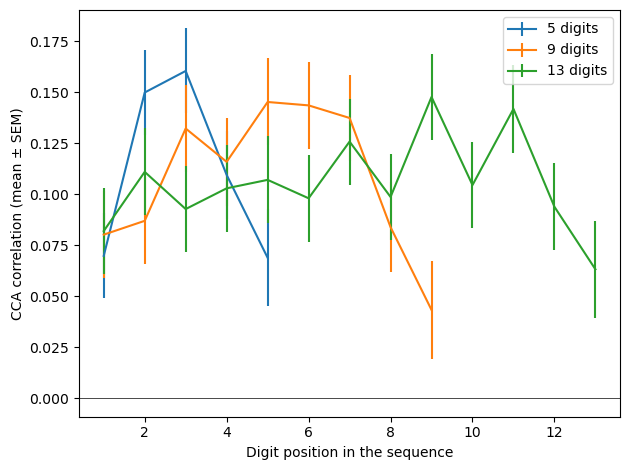

In [6]:
DIG_LEN = 200
data = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\subject_level_cca_slow.csv")
best_shift_by_sub = data.groupby("subject")["lag_ms"].agg(lambda x: x.value_counts().index[0]).to_dict()
rows_trials = []
all_rows = []
win = slice(WIN_OFFSET1, -WIN_OFFSET2)

for subj in SUBJECTS:
    print(f"Subject {subj:03d}")
    best_shift = best_shift_by_sub.get(subj, 0) // 10  # convert ms to samples
    trials_memory, trials_control = split_trials_by_condition(load_all_trials(subj))
    channels_w,  weights  = load_weights(subj)
    
    if channels_w is None or weights is None:
        print(f"Missing or ambiguous weights for subject {subj:03d}, skipping subject.")
        continue
    
    for eeg_s, pupil_s, meta in iterate_trials(trials_memory, best_shift):
        n_digits = meta['load']
        for d in range(n_digits):
            w = slice(d*DIG_LEN, (d+1)*DIG_LEN)
            cv_eeg = np.dot(eeg_s, weights)
            cv_pupil = pupil_s.ravel()

        for d in range(n_digits):
            w = slice(d * DIG_LEN, (d + 1) * DIG_LEN)
            x, y = cv_eeg[w], cv_pupil[w]
            
            if x.size == 0 or y.size == 0:
                print("Empty slice:", meta['subject'], meta['epoch'], d)
                continue

            if not np.isfinite(x).all() or not np.isfinite(y).all():
                print("Non-finite values:", meta['subject'], meta['epoch'], d, "→", np.sum(~np.isfinite(x)), "bad in X;", np.sum(~np.isfinite(y)), "bad in Y")
                continue

            if np.std(x) == 0 or np.std(y) == 0:
                print("Const window:", meta['subject'], meta['epoch'], d, np.std(x), np.std(y))
                continue

            r = pearsonr(x, y)[0]
            #r = np.corrcoef(x, y)[0, 1]

            rows_trials.append({
                'subject': meta['subject'],
                'condition': meta['condition'],
                'load': meta['load'],
                'epoch': meta['epoch'],
                'lag_ms': best_shift * 10,  # convert samples to ms
                'digit_pos': d + 1,  # 1-based digit index
                'pupil': float(np.mean(y)),  # mean pupil size in this digit
                'F1': float(np.mean(eeg_s[w, 5])),  # mean EEG, F1 signal in this digit
                'eeg_component': float(np.mean(x)),  # mean CCA component in this digit
                'r': float(r),  # convert to plain float for JSON-ability
            })

        meta['r'] = float(np.corrcoef(cv_eeg, cv_pupil)[0,1])
        meta['r'] = float(np.corrcoef(cv_eeg, cv_pupil)[0,1])
        meta['lag_ms'] = best_shift *10
        all_rows.append(meta)

df_sameW = pd.DataFrame(rows_trials)
grand = (df_sameW.query("condition == 'memory'")
           .groupby(['load','digit_pos'])['r']
           .agg(['mean','sem'])
           .reset_index())

for L in [5,9,13]:
    sub = grand[grand.load == L]
    plt.errorbar(sub.digit_pos, sub['mean'],
                 yerr=sub['sem'], label=f"{L} digits")
plt.axhline(0, c='k', lw=.5)
plt.xlabel("Digit position in the sequence")
plt.ylabel("CCA correlation (mean ± SEM)")
plt.legend(); plt.tight_layout()

pd.DataFrame(all_rows).to_csv("mem_trial_level_cca_slow.csv", index=False)
print("Finished - saved per-trial correlations with plain CCA.")

pd.DataFrame(rows_trials).to_csv("mem_digit_level_cca_slow.csv", index=False)
print("Finished - saved per-trial and digit correlations with plain CCA.")

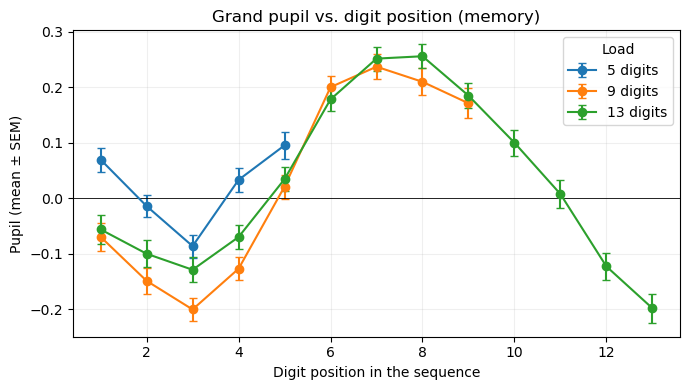

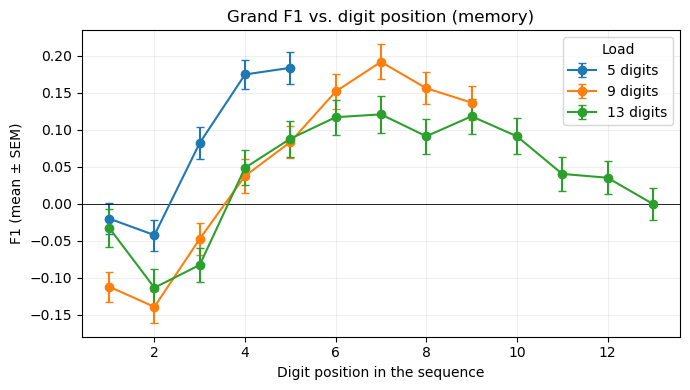

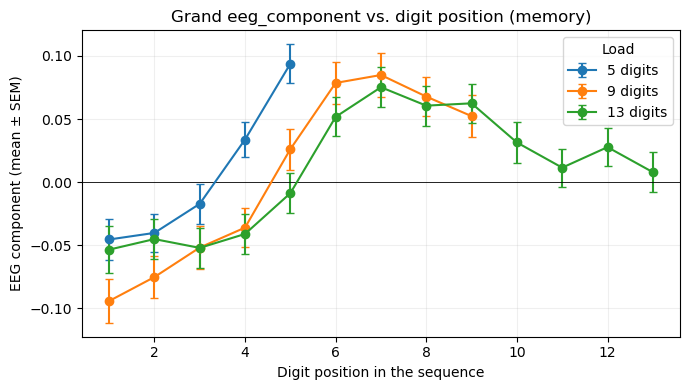

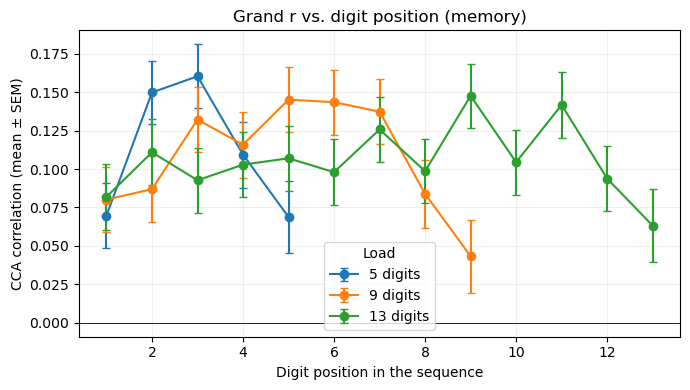

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")

# Aggregate (mean ± SEM) per load × digit_pos, memory only
agg = {"mean": "mean", "sem": "sem"}
grand = {
    "pupil": (mem.query("condition == 'memory'")
              .groupby(['load','digit_pos'])['pupil'].agg(['mean','sem']).reset_index()),
    "F1": (mem.query("condition == 'memory'")
              .groupby(['load','digit_pos'])['F1'].agg(['mean','sem']).reset_index()),
    "eeg_component": (mem.query("condition == 'memory'")
              .groupby(['load','digit_pos'])['eeg_component'].agg(['mean','sem']).reset_index()),
    "r": (mem.query("condition == 'memory'")
              .groupby(['load','digit_pos'])['r'].agg(['mean','sem']).reset_index()),
}

ylabels = {
    "F1": "F1 (mean ± SEM)",
    "pupil": "Pupil (mean ± SEM)",
    "eeg_component": "EEG component (mean ± SEM)",
    "r": "CCA correlation (mean ± SEM)",
}

loads = [5, 9, 13]

for name, df in grand.items():
    plt.figure(figsize=(7,4))
    for L in loads:
        sub = df[df["load"] == L].copy()
        # ensure numeric and sorted x
        sub["digit_pos"] = pd.to_numeric(sub["digit_pos"], errors="coerce")
        sub = sub.dropna(subset=["digit_pos"]).sort_values("digit_pos")
        plt.errorbar(sub["digit_pos"], sub["mean"], yerr=sub["sem"], marker="o", linestyle="-", capsize=3, label=f"{L} digits")
    plt.axhline(0, lw=.6, color="k")
    plt.xlabel("Digit position in the sequence")
    plt.ylabel(ylabels.get(name, f"{name} (mean ± SEM)"))
    plt.title(f"Grand {name} vs. digit position (memory)")
    plt.legend(title="Load")
    plt.grid(alpha=.2)
    plt.tight_layout()
    # plt.show()  # optional in notebooks


In [ ]:
DIG_LEN = 200
data = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\subject_level_cca_slow.csv")
best_shift_by_sub = data.groupby("subject")["lag_ms"].agg(lambda x: x.value_counts().index[0]).to_dict()
rows_trials = []
all_rows = []
win = slice(WIN_OFFSET1, -WIN_OFFSET2)

for subj in SUBJECTS:
    best_shift = best_shift_by_sub.get(subj, 0) // 10  # convert ms to samples
    trials_memory, trials_control = split_trials_by_condition(load_all_trials(subj))
    channels_w,  weights  = load_weights(subj)
    
    if channels_w is None or weights is None:
        print(f"Missing or ambiguous weights for subject {subj:03d}, skipping subject.")
        continue
    
    for eeg_s, pupil_s, meta in iterate_trials(trials_control, best_shift, win):
        n_digits = meta['load']
        for d in range(n_digits):
            w = slice(d*DIG_LEN, (d+1)*DIG_LEN)
            cv_eeg = np.dot(eeg_s, weights)
            cv_pupil = pupil_s.ravel()

        for d in range(n_digits):
            w = slice(d * DIG_LEN, (d + 1) * DIG_LEN)
            x, y = cv_eeg[w], cv_pupil[w]
            
            if x.size == 0 or y.size == 0:
                print("Empty slice:", meta['subject'], meta['epoch'], d)
                continue

            if not np.isfinite(x).all() or not np.isfinite(y).all():
                print("Non-finite values:", meta['subject'], meta['epoch'], d, "→", np.sum(~np.isfinite(x)), "bad in X;", np.sum(~np.isfinite(y)), "bad in Y")
                continue

            if np.std(x) == 0 or np.std(y) == 0:
                print("Const window:", meta['subject'], meta['epoch'], d, np.std(x), np.std(y))
                continue

            r = pearsonr(x, y)[0]
            #r = np.corrcoef(x, y)[0, 1]

            rows_trials.append({
                'subject': meta['subject'],
                'condition': meta['condition'],
                'load': meta['load'],
                'epoch': meta['epoch'],
                'lag_ms': best_shift * 10,  # convert samples to ms
                'digit_pos': d + 1,  # 1-based digit index
                'pupil': float(np.mean(y)),  # mean pupil size in this digit
                'F1': float(np.mean(eeg_s[w, 5])),  # mean EEG, F1 signal in this digit
                'eeg_component': float(np.mean(x)),  # mean CCA component in this digit
                'r': float(r),  # convert to plain float for JSON-ability
            })

        meta['r'] = float(np.corrcoef(cv_eeg, cv_pupil)[0,1])
        meta['lag_ms'] = best_shift *10
        all_rows.append(meta)

df_sameW = pd.DataFrame(rows_trials)
grand = (df_sameW.query("condition == 'control'")
           .groupby(['load','digit_pos'])['r']
           .agg(['mean','sem'])
           .reset_index())

for L in [5,9,13]:
    sub = grand[grand.load == L]
    plt.errorbar(sub.digit_pos, sub['mean'],
                 yerr=sub['sem'], label=f"{L} digits")
plt.axhline(0, c='k', lw=.5)
plt.xlabel("Digit position in the sequence")
plt.ylabel("CCA correlation (mean ± SEM)")
plt.legend(); plt.tight_layout()

pd.DataFrame(all_rows).to_csv("ctrl_trial_level_cca_slow.csv", index=False)
print("Finished - saved per-trial correlations with plain CCA.")

pd.DataFrame(rows_trials).to_csv("ctrl_digit_level_cca_slow.csv", index=False)
print("Finished - saved per-trial and digit correlations with plain CCA.")

## Comparing mem vs ctrl digits
However since we trained on memory it is biased that memory is significant

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats

# --------------------------
# Paths (edit if needed)
# --------------------------
mem_path  = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
ctrl_path = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\ctrl_digit_level_cca_slow.csv")

# --------------------------
# Load and keep needed cols
# --------------------------
cols = ["subject","condition","load","epoch","digit_pos","pupil","eeg","eeg_component","r"]
mem  = pd.read_csv(mem_path)
ctrl = pd.read_csv(ctrl_path)
mem  = mem[[c for c in cols if c in mem.columns]].copy()
ctrl = ctrl[[c for c in cols if c in ctrl.columns]].copy()

digit = 11

# Normalize keys/types
for df in (mem, ctrl):
    df["subject"]   = df["subject"].astype(str).str.strip()
    df["digit_pos"] = pd.to_numeric(df["digit_pos"], errors="coerce")
    for v in ["pupil","eeg","eeg_component","r"]:
        if v in df.columns:
            df[v] = pd.to_numeric(df[v], errors="coerce")

mem["condition"]  = "memory"
ctrl["condition"] = "control"

# --------------------------
# Filter to digit 9 only
# --------------------------
mem9  = mem.query(f"digit_pos == {digit}").copy()
ctrl9 = ctrl.query(f"digit_pos == {digit}").copy()

# --------------------------
# Mean per subject × condition
# (averaged across epochs (and loads if multiple),
#  since you asked for “take the mean for digit 5”)
# --------------------------
vars_ = ["pupil","eeg","eeg_component","r"]
mem_mean  = mem9.groupby(["subject","condition"], as_index=False)[vars_].mean(numeric_only=True)
ctrl_mean = ctrl9.groupby(["subject","condition"], as_index=False)[vars_].mean(numeric_only=True)

# Merge by subject; keep subjects that have BOTH conditions
m = (mem_mean.drop(columns="condition")
         .merge(ctrl_mean.drop(columns="condition"),
                on="subject", suffixes=("_mem","_ctrl")))

if m.empty:
    raise RuntimeError("No subjects have both memory and control data at digit_pos.")

# --------------------------
# Per-subject diffs
# --------------------------
per_subj = pd.DataFrame({"subject": m["subject"]})
for v in vars_:
    mem_v  = m[f"{v}_mem"].astype(float)
    ctrl_v = m[f"{v}_ctrl"].astype(float)
    diff   = mem_v - ctrl_v
    # relative difference vs control (percentage change if you *100)
    # handle |ctrl|=0 -> NaN
    rel    = diff / np.where(np.abs(ctrl_v) > 0, np.abs(ctrl_v), np.nan)

    per_subj[f"{v}_mean_mem"]  = mem_v
    per_subj[f"{v}_mean_ctrl"] = ctrl_v
    per_subj[f"{v}_diff"]      = diff
    per_subj[f"{v}_rel_diff"]  = rel

# Save per-subject table
out_path = Path(f"digit{digit}_per_subject_means_and_diffs.csv")
per_subj.to_csv(out_path, index=False)
print(f"Saved per-subject table: {out_path.resolve()}")

# --------------------------
# Group t-tests across subjects
# One-sample t-test on differences vs 0, one-sided (mean>0)
# --------------------------
def onesided_ttest_greater(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < 2:
        return {"n": len(x), "t": np.nan, "p_one_sided": np.nan}
    t, p_two = stats.ttest_1samp(x, popmean=0.0, nan_policy="omit")
    # one-sided for mean>0
    p_one = p_two/2 if t > 0 else 1 - p_two/2
    return {"n": len(x), "t": float(t), "p_one_sided": float(p_one)}

rows = []
for v in vars_:
    res_rel = onesided_ttest_greater(per_subj[f"{v}_rel_diff"])
    res_abs = onesided_ttest_greater(per_subj[f"{v}_diff"])
    rows.append({
        "variable": v,
        "RELDIFF_n": res_rel["n"],
        "RELDIFF_t": res_rel["t"],
        "RELDIFF_p_one_sided": res_rel["p_one_sided"],
        "RELDIFF_sig_0p05": (res_rel["p_one_sided"] < 0.05) if np.isfinite(res_rel["p_one_sided"]) else False,
        "ABSDIFF_n": res_abs["n"],
        "ABSDIFF_t": res_abs["t"],
        "ABSDIFF_p_one_sided": res_abs["p_one_sided"],
        "ABSDIFF_sig_0p05": (res_abs["p_one_sided"] < 0.05) if np.isfinite(res_abs["p_one_sided"]) else False,
        "mean_rel_diff": np.nanmean(per_subj[f"{v}_rel_diff"].to_numpy(dtype=float)),
        "mean_abs_diff": np.nanmean(per_subj[f"{v}_diff"].to_numpy(dtype=float)),
    })

summary = pd.DataFrame(rows)
sum_path = Path(f"digit{digit}_group_ttests_summary.csv")
summary.to_csv(sum_path, index=False)
print(f"Saved group summary: {sum_path.resolve()}")

print(f"\n=== Group t-tests (digit {digit}) ===")
print(summary.to_string(index=False))


## ANOVA for difference across digits within subjects (memory condition)

In [1]:
import pandas as pd
import numpy as np
import pingouin as pg

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
vars_ = ["pupil","F1","eeg_component","r"]
for v in vars_:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")

# subject × digit means (pool epochs, ignore load)
means = (mem.dropna(subset=["subject","digit_pos"] + vars_)
           .groupby(["subject","digit_pos"], as_index=False)[vars_]
           .mean())

# --- RM-ANOVA and pairwise (same as before, but on 'means') ---
results = []
pairs = []
for v in vars_:
    long = means[["subject","digit_pos", v]].dropna()
    wide = long.pivot(index="subject", columns="digit_pos", values=v)
    keep = wide.dropna(axis=0, how="any")
    if keep.shape[0] < 2 or keep.shape[1] < 2:
        continue
    long_bal = keep.reset_index().melt(id_vars="subject", var_name="digit_pos", value_name=v)
    long_bal["digit_pos"] = long_bal["digit_pos"].astype(int)

    # RM-ANOVA
    aov = pg.rm_anova(data=long_bal, dv=v, within="digit_pos", subject="subject", detailed=True)

    # Sphericity & epsilon (your version)
    spher, W, chi2, dof, p_spher = pg.sphericity(keep, method="mauchly")
    eps_res = pg.epsilon(keep)
    try:
        eps_GG = float(eps_res.get("gg", np.nan))
        eps_HF = float(eps_res.get("hf", np.nan))
    except AttributeError:
        eps_GG = float(eps_res); eps_HF = np.nan

    results.append({
        "variable": v,
        "n_subjects": keep.shape[0],
        "n_digits": keep.shape[1],
        "F": aov.loc[0,"F"],
        "p-unc": aov.loc[0,"p-unc"],
        "p-GG-corr": aov.loc[0].get("p-GG-corr", np.nan),
        "sphericity": bool(spher),
        "W_sphericity": float(W),
        "chi2_sphericity": float(chi2),
        "dof_sphericity": int(dof),
        "p_sphericity": float(p_spher),
        "eps_GG": eps_GG,
        "eps_HF": eps_HF
    })

    # Pairwise within-subjects with FDR, Cohen's d (paired)
    ph = pg.pairwise_tests(data=long_bal, dv=v, within="digit_pos", subject="subject",
                           padjust="fdr_bh", effsize="cohen", return_desc=False)
    ph = ph[["A","B","T","dof","p-unc","p-corr","p-adjust","cohen"]].copy()
    ph.insert(0, "variable", v)
    pairs.append(ph)

pd.DataFrame(results).to_csv("rm_anova_memory_only.csv", index=False)
pd.concat(pairs, ignore_index=True).to_csv("pairwise_memory_only.csv", index=False)

print(pd.DataFrame(results).to_string(index=False))
print("\nPairwise post-hoc tests:")
print(pd.concat(pairs, ignore_index=True).to_string(index=False))

     variable  n_subjects  n_digits         F        p-unc    p-GG-corr  sphericity  W_sphericity  chi2_sphericity  dof_sphericity  p_sphericity   eps_GG  eps_HF
        pupil          56        13 10.567403 2.612276e-19 4.831207e-06       False  1.340652e-08       920.978947              77 9.555843e-144 0.229974     NaN
           F1          56        13  7.981749 4.708424e-14 1.292088e-07       False  8.620750e-02       124.524321              77  5.489602e-04 0.463817     NaN
eeg_component          56        13  5.778411 1.481968e-09 2.325168e-04       False  5.472122e-03       264.599844              77  3.475913e-22 0.323173     NaN
            r          56        13  1.982784 2.339750e-02 7.535532e-02       False  1.482751e-03       330.940074              77  6.945423e-33 0.450926     NaN

Pairwise post-hoc tests:
     variable  A  B         T  dof        p-unc       p-corr p-adjust     cohen
        pupil  1  2  1.734444 55.0 8.844117e-02 1.299957e-01   fdr_bh  0.160770
    

In [8]:
import pandas as pd
from pathlib import Path

# --- Path to your file ---
in_path = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\pairwise_memory_only.csv")

# --- Read ---
df = pd.read_csv(in_path)

# Safety: normalize column name just in case of stray spaces/casing
df.columns = [c.strip() for c in df.columns]

# --- Filter p-corr < 0.05 ---
sig = df[df['p-corr'] < 0.05].copy().sort_values(['variable','A','B'])

print("Significant pairs (p-corr < 0.05):")
if sig.empty:
    print("None.")
else:
    # Show a compact view
    print(sig[['variable','A','B','T','dof','cohen','p-unc','p-corr']].to_string(index=False))

# --- Save filtered CSV ---
out_csv = in_path.with_name(in_path.stem + "_significant_two.csv")
sig.to_csv(out_csv, index=False)
print(f"\nSaved: {out_csv}")


Significant pairs (p-corr < 0.05):
     variable  A  B         T  dof     cohen        p-unc       p-corr
           F1  1  3 -2.285323 55.0 -0.433473 2.617256e-02 4.979169e-02
           F1  1  4 -4.684094 55.0 -1.056686 1.885850e-05 1.574675e-04
           F1  1  5 -5.036826 55.0 -1.186692 5.431207e-06 7.060570e-05
           F1  1  6 -4.800033 55.0 -1.108594 1.256785e-05 1.400417e-04
           F1  1  7 -4.501835 55.0 -1.063452 3.543271e-05 2.303126e-04
           F1  1  8 -3.408054 55.0 -0.752411 1.230589e-03 5.051892e-03
           F1  1  9 -4.664531 55.0 -1.016556 2.018815e-05 1.574675e-04
           F1  1 10 -2.342550 55.0 -0.467564 2.279875e-02 4.559750e-02
           F1  1 12 -2.693230 55.0 -0.549613 9.361866e-03 2.147722e-02
           F1  2  3 -4.758758 55.0 -0.600010 1.452704e-05 1.416387e-04
           F1  2  4 -6.117549 55.0 -1.243783 1.038402e-07 4.049769e-06
           F1  2  5 -6.428413 55.0 -1.383670 3.244422e-08 2.530649e-06
           F1  2  6 -5.968394 55.0 -1.2824

In [ ]:
import pandas as pd
import numpy as np
import pingouin as pg

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem5 = mem[mem["load"] == 5]
mem5["subject"] = mem5["subject"].astype(str).str.strip()
mem5["digit_pos"] = pd.to_numeric(mem5["digit_pos"], errors="coerce")
vars_ = ["pupil","F1","eeg_component","r"]
for v in vars_:
    mem5[v] = pd.to_numeric(mem5[v], errors="coerce")

# subject × digit means (pool epochs, ignore load)
means5 = (mem5.dropna(subset=["subject","digit_pos"] + vars_)
           .groupby(["subject","digit_pos"], as_index=False)[vars_]
           .mean())

# --- RM-ANOVA and pairwise (same as before, but on 'means') ---
results = []
pairs = []
for v in vars_:
    long = means5[["subject","digit_pos", v]].dropna()
    wide = long.pivot(index="subject", columns="digit_pos", values=v)
    keep = wide.dropna(axis=0, how="any")
    if keep.shape[0] < 2 or keep.shape[1] < 2:
        continue
    long_bal = keep.reset_index().melt(id_vars="subject", var_name="digit_pos", value_name=v)
    long_bal["digit_pos"] = long_bal["digit_pos"].astype(int)

    # RM-ANOVA
    aov = pg.rm_anova(data=long_bal, dv=v, within="digit_pos", subject="subject", detailed=True)

    # Sphericity & epsilon (your version)
    spher, W, chi2, dof, p_spher = pg.sphericity(keep, method="mauchly")
    eps_res = pg.epsilon(keep)
    try:
        eps_GG = float(eps_res.get("gg", np.nan))
        eps_HF = float(eps_res.get("hf", np.nan))
    except AttributeError:
        eps_GG = float(eps_res); eps_HF = np.nan

    results.append({
        "variable": v,
        "n_subjects": keep.shape[0],
        "n_digits": keep.shape[1],
        "F": aov.loc[0,"F"],
        "p-unc": aov.loc[0,"p-unc"],
        "p-GG-corr": aov.loc[0].get("p-GG-corr", np.nan),
        "sphericity": bool(spher),
        "W_sphericity": float(W),
        "chi2_sphericity": float(chi2),
        "dof_sphericity": int(dof),
        "p_sphericity": float(p_spher),
        "eps_GG": eps_GG,
        "eps_HF": eps_HF
    })

    # Pairwise within-subjects with FDR, Cohen's d (paired)
    ph = pg.pairwise_tests(data=long_bal, dv=v, within="digit_pos", subject="subject",
                           padjust="fdr_bh", effsize="cohen", return_desc=False)
    ph = ph[["A","B","T","dof","p-unc","p-corr","p-adjust","cohen"]].copy()
    ph.insert(0, "variable", v)
    pairs.append(ph)

pd.DataFrame(results).to_csv("rm_anova_memory5_only.csv", index=False)
pd.concat(pairs, ignore_index=True).to_csv("pairwise_memory5_only.csv", index=False)

print(pd.DataFrame(results).to_string(index=False))
print("\nPairwise post-hoc tests:")
print(pd.concat(pairs, ignore_index=True).to_string(index=False))

C:\Users\cdd\AppData\Local\Temp\ipykernel_10956\3005845650.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mem5["subject"] = mem5["subject"].astype(str).str.strip()
C:\Users\cdd\AppData\Local\Temp\ipykernel_10956\3005845650.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mem5["digit_pos"] = pd.to_numeric(mem5["digit_pos"], errors="coerce")
C:\Users\cdd\AppData\Local\Temp\ipykernel_10956\3005845650.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try 

     variable  n_subjects  n_digits         F        p-unc    p-GG-corr  sphericity  W_sphericity  chi2_sphericity  dof_sphericity  p_sphericity   eps_GG  eps_HF
        pupil          57         5  4.023448 3.588525e-03 2.981712e-02       False      0.033146       185.389286               9  4.644904e-35 0.395106     NaN
           F1          57         5 15.887714 1.830462e-11 6.353019e-07       False      0.060114       152.992713               9  2.439890e-28 0.513073     NaN
eeg_component          57         5  7.308586 1.503793e-05 9.818135e-04       False      0.066102       147.826042               9  2.844223e-27 0.506591     NaN
            r          57         5  4.491501 1.646344e-03 3.037502e-03       False      0.720221        17.859430               9  3.692004e-02 0.851682     NaN

Pairwise post-hoc tests:
     variable A B         T  dof        p-unc   p-corr p-adjust     cohen
        pupil 1 2  2.147899 56.0 3.606301e-02 0.072126   fdr_bh  0.281538
        pupil 1 

In [ ]:
import pandas as pd
import numpy as np
import pingouin as pg

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem9 = mem[mem["load"] == 9]
mem9["subject"] = mem9["subject"].astype(str).str.strip()
mem9["digit_pos"] = pd.to_numeric(mem9["digit_pos"], errors="coerce")
vars_ = ["pupil","F1","eeg_component","r"]
for v in vars_:
    mem9[v] = pd.to_numeric(mem9[v], errors="coerce")

# subject × digit means (pool epochs, ignore load)
means9 = (mem9.dropna(subset=["subject","digit_pos"] + vars_)
           .groupby(["subject","digit_pos"], as_index=False)[vars_]
           .mean())

# --- RM-ANOVA and pairwise (same as before, but on 'means9') ---
results = []
pairs = []
for v in vars_:
    long = means9[["subject","digit_pos", v]].dropna()
    wide = long.pivot(index="subject", columns="digit_pos", values=v)
    keep = wide.dropna(axis=0, how="any")
    if keep.shape[0] < 2 or keep.shape[1] < 2:
        continue
    long_bal = keep.reset_index().melt(id_vars="subject", var_name="digit_pos", value_name=v)
    long_bal["digit_pos"] = long_bal["digit_pos"].astype(int)

    # RM-ANOVA
    aov = pg.rm_anova(data=long_bal, dv=v, within="digit_pos", subject="subject", detailed=True)

    # Sphericity & epsilon (your version)
    spher, W, chi2, dof, p_spher = pg.sphericity(keep, method="mauchly")
    eps_res = pg.epsilon(keep)
    try:
        eps_GG = float(eps_res.get("gg", np.nan))
        eps_HF = float(eps_res.get("hf", np.nan))
    except AttributeError:
        eps_GG = float(eps_res); eps_HF = np.nan

    results.append({
        "variable": v,
        "n_subjects": keep.shape[0],
        "n_digits": keep.shape[1],
        "F": aov.loc[0,"F"],
        "p-unc": aov.loc[0,"p-unc"],
        "p-GG-corr": aov.loc[0].get("p-GG-corr", np.nan),
        "sphericity": bool(spher),
        "W_sphericity": float(W),
        "chi2_sphericity": float(chi2),
        "dof_sphericity": int(dof),
        "p_sphericity": float(p_spher),
        "eps_GG": eps_GG,
        "eps_HF": eps_HF
    })

    # Pairwise within-subjects with FDR, Cohen's d (paired)
    ph = pg.pairwise_tests(data=long_bal, dv=v, within="digit_pos", subject="subject",
                           padjust="fdr_bh", effsize="cohen", return_desc=False)
    ph = ph[["A","B","T","dof","p-unc","p-corr","p-adjust","cohen"]].copy()
    ph.insert(0, "variable", v)
    pairs.append(ph)

pd.DataFrame(results).to_csv("rm_anova_memory9_only.csv", index=False)
pd.concat(pairs, ignore_index=True).to_csv("pairwise_memory9_only.csv", index=False)

print(pd.DataFrame(results).to_string(index=False))
print("\nPairwise post-hoc tests:")
print(pd.concat(pairs, ignore_index=True).to_string(index=False))

C:\Users\cdd\AppData\Local\Temp\ipykernel_10956\857986394.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mem9["subject"] = mem9["subject"].astype(str).str.strip()
C:\Users\cdd\AppData\Local\Temp\ipykernel_10956\857986394.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mem9["digit_pos"] = pd.to_numeric(mem9["digit_pos"], errors="coerce")
C:\Users\cdd\AppData\Local\Temp\ipykernel_10956\857986394.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usi

     variable  n_subjects  n_digits         F        p-unc    p-GG-corr  sphericity  W_sphericity  chi2_sphericity  dof_sphericity  p_sphericity   eps_GG  eps_HF
        pupil          55         9 12.529646 3.264857e-16 1.929477e-05       False      0.000029       534.277325              35  4.962371e-90 0.237577     NaN
           F1          55         9 12.962155 8.727470e-17 6.963552e-10       False      0.002850       299.620279              35  1.674774e-43 0.527650     NaN
eeg_component          55         9  7.745572 1.002818e-09 3.535497e-04       False      0.194119        83.808291              35  7.395946e-06 0.288450     NaN
            r          55         9  2.899054 3.704438e-03 1.023896e-02       False      0.236699        73.669316              35  1.499428e-04 0.717972     NaN

Pairwise post-hoc tests:
     variable A B         T  dof        p-unc   p-corr p-adjust     cohen
        pupil 1 2  1.422638 54.0 1.605926e-01 0.222359   fdr_bh  0.144344
        pupil 1 

In [2]:
import pandas as pd
import numpy as np
import pingouin as pg

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem13 = mem[mem["load"] == 13]
mem13["subject"] = mem13["subject"].astype(str).str.strip()
mem13["digit_pos"] = pd.to_numeric(mem13["digit_pos"], errors="coerce")
vars_ = ["pupil","F1","eeg_component","r"]
for v in vars_:
    mem13[v] = pd.to_numeric(mem13[v], errors="coerce")

# subject × digit means (pool epochs, ignore load)
means13 = (mem13.dropna(subset=["subject","digit_pos"] + vars_)
           .groupby(["subject","digit_pos"], as_index=False)[vars_]
           .mean())

# --- RM-ANOVA and pairwise (same as before, but on 'means13') ---
results = []
pairs = []
for v in vars_:
    long = means13[["subject","digit_pos", v]].dropna()
    wide = long.pivot(index="subject", columns="digit_pos", values=v)
    keep = wide.dropna(axis=0, how="any")
    if keep.shape[0] < 2 or keep.shape[1] < 2:
        continue
    long_bal = keep.reset_index().melt(id_vars="subject", var_name="digit_pos", value_name=v)
    long_bal["digit_pos"] = long_bal["digit_pos"].astype(int)

    # RM-ANOVA
    aov = pg.rm_anova(data=long_bal, dv=v, within="digit_pos", subject="subject", detailed=True)

    # Sphericity & epsilon (your version)
    spher, W, chi2, dof, p_spher = pg.sphericity(keep, method="mauchly")
    eps_res = pg.epsilon(keep)
    try:
        eps_GG = float(eps_res.get("gg", np.nan))
        eps_HF = float(eps_res.get("hf", np.nan))
    except AttributeError:
        eps_GG = float(eps_res); eps_HF = np.nan

    results.append({
        "variable": v,
        "n_subjects": keep.shape[0],
        "n_digits": keep.shape[1],
        "F": aov.loc[0,"F"],
        "p-unc": aov.loc[0,"p-unc"],
        "p-GG-corr": aov.loc[0].get("p-GG-corr", np.nan),
        "sphericity": bool(spher),
        "W_sphericity": float(W),
        "chi2_sphericity": float(chi2),
        "dof_sphericity": int(dof),
        "p_sphericity": float(p_spher),
        "eps_GG": eps_GG,
        "eps_HF": eps_HF
    })

    # Pairwise within-subjects with FDR, Cohen's d (paired)
    ph = pg.pairwise_tests(data=long_bal, dv=v, within="digit_pos", subject="subject",
                           padjust="fdr_bh", effsize="cohen", return_desc=False)
    ph = ph[["A","B","T","dof","p-unc","p-corr","p-adjust","cohen"]].copy()
    ph.insert(0, "variable", v)
    pairs.append(ph)

pd.DataFrame(results).to_csv("rm_anova_memory13_only.csv", index=False)
pd.concat(pairs, ignore_index=True).to_csv("pairwise_memory13_only.csv", index=False)

print(pd.DataFrame(results).to_string(index=False))
print("\nPairwise post-hoc tests:")
print(pd.concat(pairs, ignore_index=True).to_string(index=False))

C:\Users\cdd\AppData\Local\Temp\ipykernel_35000\2547525913.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mem13["subject"] = mem13["subject"].astype(str).str.strip()
C:\Users\cdd\AppData\Local\Temp\ipykernel_35000\2547525913.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mem13["digit_pos"] = pd.to_numeric(mem13["digit_pos"], errors="coerce")
C:\Users\cdd\AppData\Local\Temp\ipykernel_35000\2547525913.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.


     variable  n_subjects  n_digits        F        p-unc  p-GG-corr  sphericity  W_sphericity  chi2_sphericity  dof_sphericity  p_sphericity   eps_GG  eps_HF
        pupil          56        13 7.772523 1.260694e-13   0.000166       False  2.873730e-08       882.242024              77 4.573513e-136 0.218385     NaN
           F1          56        13 3.957684 6.393444e-06   0.001837       False  1.274544e-02       221.643386              77  9.060491e-16 0.412055     NaN
eeg_component          56        13 4.308153 1.316430e-06   0.001970       False  6.278554e-03       257.615439              77  4.136814e-21 0.344653     NaN
            r          56        13 1.850756 3.742671e-02   0.104583       False  3.641399e-03       285.292874              77  1.956904e-25 0.409332     NaN

Pairwise post-hoc tests:
     variable  A  B         T  dof        p-unc   p-corr p-adjust     cohen
        pupil  1  2 -0.253118 55.0 8.011208e-01 0.853129   fdr_bh -0.018438
        pupil  1  3  0.4700

In [ ]:
import pandas as pd
from pathlib import Path

# --- Path to your file ---
in_path = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\pairwise_memory5_only.csv")

# --- Read ---
df = pd.read_csv(in_path)

# Safety: normalize column name just in case of stray spaces/casing
df.columns = [c.strip() for c in df.columns]

# --- Filter p-corr < 0.05 ---
sig = df[df['p-corr'] < 0.05].copy().sort_values(['variable','A','B'])

print("Significant pairs (p-corr < 0.05):")
if sig.empty:
    print("None.")
else:
    # Show a compact view
    print(sig[['variable','A','B','T','dof','cohen','p-unc','p-corr']].to_string(index=False))

# --- Save filtered CSV ---
out_csv = in_path.with_name(in_path.stem + "_significant2.csv")
sig.to_csv(out_csv, index=False)
print(f"\nSaved: {out_csv}")


Significant pairs (p-corr < 0.05):
     variable  A  B         T  dof     cohen        p-unc   p-corr
           F1  1  3 -2.598388 56.0 -0.612952 1.194839e-02 0.017069
           F1  1  4 -4.241910 56.0 -1.035432 8.392260e-05 0.000173
           F1  1  5 -4.232224 56.0 -1.007659 8.670463e-05 0.000173
           F1  2  3 -4.324321 56.0 -0.756830 6.350854e-05 0.000173
           F1  2  4 -5.712744 56.0 -1.272946 4.436931e-07 0.000004
           F1  2  5 -5.449904 56.0 -1.208110 1.170723e-06 0.000006
           F1  3  4 -3.293266 56.0 -0.442034 1.719612e-03 0.002866
           F1  3  5 -2.357543 56.0 -0.446182 2.191582e-02 0.027395
eeg_component  1  5 -3.018309 56.0 -0.715332 3.821449e-03 0.009554
eeg_component  2  4 -2.629704 56.0 -0.557745 1.101340e-02 0.018356
eeg_component  2  5 -4.062517 56.0 -0.849861 1.527106e-04 0.001527
eeg_component  3  4 -2.745590 56.0 -0.381991 8.105209e-03 0.016210
eeg_component  3  5 -3.443998 56.0 -0.681490 1.092313e-03 0.005462
eeg_component  4  5 -3.2052

In [14]:
# --- BIN DIGITS: early(1-3), mid(7-9), late(11-13) ---
bin_map = {
    "early": {1,2,3},
    "mid":   {7,8,9},
    "late":  {11,12,13},
}
def digit_bin(d):
    for k, S in bin_map.items():
        if int(d) in S:
            return k
    return np.nan  # ignore digits not in the three windows

binned = means.copy()
binned["bin3"] = binned["digit_pos"].map(digit_bin)
binned = binned.dropna(subset=["bin3"])


In [15]:
# --- INVERTED-U: within-subject bin tests using SciPy (no DataFrame indexing gotchas) ---
import numpy as np
from scipy.stats import ttest_rel

def within_subject_bin_tests(df, v):
    # subject-level means per bin (paired design)
    wide = (df[["subject","bin3", v]]
            .dropna()
            .groupby(["subject","bin3"], as_index=False)[v].mean()
            .pivot(index="subject", columns="bin3", values=v))

    # keep subjects with all three bins
    need = {"early","mid","late"}
    if not need.issubset(set(wide.columns)):
        # add any missing columns so .dropna works cleanly
        for col in need - set(wide.columns):
            wide[col] = np.nan
    wide = wide.dropna(subset=["early","mid","late"], how="any")

    n = wide.shape[0]
    if n < 5:
        return None

    # paired arrays
    e = wide["early"].to_numpy(dtype=float)
    m = wide["mid"].to_numpy(dtype=float)
    l = wide["late"].to_numpy(dtype=float)

    # one-sided paired t-tests: H1 mid > early, mid > late
    t_me, p_me = ttest_rel(m, e, alternative="greater")
    t_ml, p_ml = ttest_rel(m, l, alternative="greater")

    # Cohen's dz for paired differences
    def cohen_dz(a, b):
        d = a - b
        return d.mean() / d.std(ddof=1)

    return {
        "n_subjects": int(n),
        "mid>early_t": float(t_me), "mid>early_p": float(p_me), "dz_me": float(cohen_dz(m, e)),
        "mid>late_t":  float(t_ml), "mid>late_p":  float(p_ml), "dz_ml": float(cohen_dz(m, l)),
        "mean(early)": float(e.mean()), "mean(mid)": float(m.mean()), "mean(late)": float(l.mean()),
    }

bin_tests = []
for v in vars_:
    res = within_subject_bin_tests(binned, v)
    if res:
        res["variable"] = v
        bin_tests.append(res)

bin_df = pd.DataFrame(bin_tests)
bin_df.to_csv("invertedU_bin_tests.csv", index=False)
print(bin_df.to_string(index=False))


 n_subjects  mid>early_t  mid>early_p    dz_me  mid>late_t  mid>late_p    dz_ml  mean(early)  mean(mid)  mean(late)      variable
         56     4.387137     0.000026 0.586256    5.006721    0.000003 0.669051    -0.126452   0.244000   -0.057976         pupil
         56     3.339663     0.000756 0.446281    2.388900    0.010178 0.319230    -0.061657   0.097227    0.017055            F1
         56     2.974973     0.002173 0.397547    2.251291    0.014191 0.300841    -0.057781   0.076900    0.016980 eeg_component
         56     0.845132     0.200849 0.112936    1.556078    0.062713 0.207940     0.110519   0.134936    0.105279             r


In [5]:
import statsmodels.formula.api as smf
import numpy as np

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
vars_ = ["pupil","F1","eeg_component","r"]
for v in vars_:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")

# subject × digit means (pool epochs, ignore load)
means = (mem.dropna(subset=["subject","digit_pos"] + vars_)
           .groupby(["subject","digit_pos"], as_index=False)[vars_]
           .mean())

df = means[["subject","digit_pos","pupil","F1","eeg_component", "r"]].dropna().copy()

# z-score helps numerics, not required
for c in ["pupil","F1","eeg_component"]:
    mu, sd = df[c].mean(), df[c].std(ddof=1)
    if sd > 0: df[c] = (df[c] - mu)/sd

# OLS with subject dummies; cluster SEs by subject
m_full = smf.ols("digit_pos ~ pupil + F1 + eeg_component + r + C(subject)", data=df) \
            .fit(cov_type="cluster", cov_kwds={"groups": df["subject"]})
print(m_full.summary().tables[1])

# Test EEG coefficient (H0: eeg_component = 0; H1: > 0)
print("\nWald test for EEG > 0:")
print(m_full.t_test("eeg_component = 0"))
# For one-sided p (greater), halve the two-sided p if coef > 0:
coef = m_full.params["eeg_component"]
p_two = float(m_full.t_test("eeg_component = 0").pvalue)
p_one = p_two/2 if coef > 0 else 1 - p_two/2
print(f"EEG coef = {coef:.3f}, one-sided p = {p_one:.3g}")


                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 6.8933      0.268     25.681      0.000       6.367       7.419
C(subject)[T.sub-034]     0.0571      0.357      0.160      0.873      -0.643       0.758
C(subject)[T.sub-035]    -0.2097      0.654     -0.321      0.749      -1.492       1.073
C(subject)[T.sub-036]     0.3042      0.177      1.714      0.087      -0.044       0.652
C(subject)[T.sub-038]     0.4034      0.197      2.051      0.040       0.018       0.789
C(subject)[T.sub-039]     0.2033      0.453      0.449      0.653      -0.684       1.091
C(subject)[T.sub-040]     0.2998      0.635      0.472      0.637      -0.944       1.544
C(subject)[T.sub-041]     0.4893      0.251      1.951      0.051      -0.002       0.981
C(subject)[T.sub-042]     0.0113      0.194      0.058      0.953      -0.368       0.391
C(subject)

c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 60, but rank is 4
  warnings.warn('covariance of constraints does not have full '


In [9]:
print("R² =", m_full.rsquared, " |  Adj. R² =", m_full.rsquared_adj)
# Subject-demean y and X (within transformation)
tmp = df.copy()
for col in ["digit_pos","pupil","F1","eeg_component", "r"]:
    tmp[col] = tmp[col] - tmp.groupby("subject")[col].transform("mean")

wmod = smf.ols("digit_pos ~ pupil + F1 + eeg_component + r - 1", data=tmp).fit()
# (- 1 removes intercept because demeaned variables have mean ~ 0)
print("Within-subject R² =", wmod.rsquared)


R² = 0.07170630019856372  |  Adj. R² = -0.011177065855135782
Within-subject R² = 0.06268459635134593


In [10]:
m_red = smf.ols("digit_pos ~ pupil + F1 + C(subject)", data=df).fit()
m_full = smf.ols("digit_pos ~ pupil + F1 + eeg_component + r +C(subject)", data=df).fit()

SSE_red  = np.sum(m_red.resid**2)
SSE_full = np.sum(m_full.resid**2)
partial_R2_eeg = (SSE_red - SSE_full) / SSE_red
print("Partial R² (EEG | F1,pupil) =", partial_R2_eeg)


Partial R² (EEG | F1,pupil) = 0.05438663955869818


In [11]:
import statsmodels.formula.api as smf
import numpy as np


# OLS with subject dummies; cluster SEs by subject
m_not_eeg = smf.ols("digit_pos ~ pupil + F1 + C(subject)", data=df) \
            .fit(cov_type="cluster", cov_kwds={"groups": df["subject"]})
print(m_not_eeg.summary().tables[1])

print("R² =", m_not_eeg.rsquared, " |  Adj. R² =", m_full.rsquared_adj)
# Subject-demean y and X (within transformation)
tmp = df.copy()
for col in ["digit_pos","pupil","F1"]:
    tmp[col] = tmp[col] - tmp.groupby("subject")[col].transform("mean")

wmod = smf.ols("digit_pos ~ pupil + F1 - 1", data=tmp).fit()
# (- 1 removes intercept because demeaned variables have mean ~ 0)
print("Within-subject R² =", wmod.rsquared)



                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 7.2149      0.246     29.316      0.000       6.732       7.697
C(subject)[T.sub-034]    -0.3291      0.349     -0.943      0.346      -1.013       0.355
C(subject)[T.sub-035]    -0.6752      0.548     -1.231      0.218      -1.750       0.400
C(subject)[T.sub-036]    -0.0774      0.145     -0.536      0.592      -0.361       0.206
C(subject)[T.sub-038]    -0.0596      0.137     -0.436      0.663      -0.328       0.208
C(subject)[T.sub-039]    -0.3480      0.421     -0.826      0.409      -1.174       0.478
C(subject)[T.sub-040]    -0.4734      0.604     -0.783      0.433      -1.658       0.711
C(subject)[T.sub-041]     0.0253      0.215      0.118      0.906      -0.397       0.447
C(subject)[T.sub-042]    -0.1963      0.193     -1.019      0.308      -0.574       0.181
C(subject)

c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 58, but rank is 2
  warnings.warn('covariance of constraints does not have full '


In [30]:
import pandas as pd, numpy as np, statsmodels.api as sm, statsmodels.formula.api as smf

# 1) Load raw trial-level data
mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
for v in ["pupil","F1","eeg_component","r"]:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")
mem = mem.dropna(subset=["subject","epoch","digit_pos","pupil","F1","eeg_component"])

# (optional) focus on memory condition
# mem = mem[mem["condition"].eq("memory")]

# 2) Demean within (subject × epoch): isolates within-trial relations
grp = mem.groupby(["subject","epoch"])
mem["digit_pos_wt"] = mem["digit_pos"] - grp["digit_pos"].transform("mean")
mem["pupil_wt"]     = mem["pupil"]     - grp["pupil"].transform("mean")
mem["F1_wt"]        = mem["F1"]        - grp["F1"].transform("mean")
mem["eeg_wt"]       = mem["eeg_component"] - grp["eeg_component"].transform("mean")
mem["r_wt"]         = mem["r"]         - grp["r"].transform("mean")

# Optional: z-score predictors AFTER demeaning (across all rows) for comparability
for c in ["pupil_wt","F1_wt","eeg_wt","r_wt"]:
    mu, sd = mem[c].mean(), mem[c].std(ddof=1)
    if sd > 0: mem[c] = (mem[c] - mu)/sd

# 3) OLS with subject fixed effects and cluster-robust SEs by subject
mem["subtrial"] = mem["subject"].astype(str) + "|" + mem["epoch"].astype(str)
m_trial = smf.ols("digit_pos_wt ~ pupil_wt + F1_wt + eeg_wt + r_wt + C(subject)", data=mem) \
             .fit(cov_type="cluster", cov_kwds={"groups": mem["subtrial"]})


print(m_trial.summary().tables[1])     # coefficients table
print("Within-trial R² =", m_trial.rsquared)

# 4) Unique contribution of EEG at trial-level: partial R² (EEG | pupil,F1)
m_red = smf.ols("digit_pos_wt ~ pupil_wt + F1_wt + C(subject)", data=mem).fit()
SSE_red  = np.sum(m_red.resid**2)
SSE_full = np.sum(m_trial.resid**2)
partial_R2_eeg = (SSE_red - SSE_full) / SSE_red
print("Partial R² (EEG | F1,pupil) at trial-level =", partial_R2_eeg)


c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 60, but rank is 4
  warnings.warn('covariance of constraints does not have full '


                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              -9.61e-14   1.01e-14     -9.554      0.000   -1.16e-13   -7.64e-14
C(subject)[T.sub-034]   9.61e-14   1.01e-14      9.553      0.000    7.64e-14    1.16e-13
C(subject)[T.sub-035]  9.612e-14   1.01e-14      9.525      0.000    7.63e-14    1.16e-13
C(subject)[T.sub-036]  9.567e-14   1.02e-14      9.408      0.000    7.57e-14    1.16e-13
C(subject)[T.sub-038]  9.653e-14   1.02e-14      9.471      0.000    7.66e-14    1.17e-13
C(subject)[T.sub-039]  9.721e-14   1.01e-14      9.592      0.000    7.73e-14    1.17e-13
C(subject)[T.sub-040]  9.757e-14   1.02e-14      9.600      0.000    7.76e-14    1.17e-13
C(subject)[T.sub-041]  9.722e-14      1e-14      9.694      0.000    7.76e-14    1.17e-13
C(subject)[T.sub-042]  9.703e-14   9.99e-15      9.714      0.000    7.75e-14    1.17e-13
C(subject)

In [ ]:
import pandas as pd, numpy as np, statsmodels.api as sm, statsmodels.formula.api as smf

# 1) Load raw trial-level data
mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
for v in ["pupil","F1","eeg_component","r"]:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")
mem = mem.dropna(subset=["subject","epoch","digit_pos","pupil","F1","eeg_component"])

# (optional) focus on memory condition
# mem = mem[mem["condition"].eq("memory")]

# 2) Demean within (subject × epoch): isolates within-trial relations
grp = mem.groupby(["subject","epoch"])
mem["digit_pos_wt"] = mem["digit_pos"] - grp["digit_pos"].transform("mean")
mem["pupil_wt"]     = mem["pupil"]     - grp["pupil"].transform("mean")
mem["F1_wt"]        = mem["F1"]        - grp["F1"].transform("mean")
mem["eeg_wt"]       = mem["eeg_component"] - grp["eeg_component"].transform("mean")
mem["r_wt"]         = mem["r"]         - grp["r"].transform("mean")

# Optional: z-score predictors AFTER demeaning (across all rows) for comparability
for c in ["pupil_wt","F1_wt","eeg_wt","r_wt"]:
    mu, sd = mem[c].mean(), mem[c].std(ddof=1)
    if sd > 0: mem[c] = (mem[c] - mu)/sd

# 3) OLS with subject fixed effects and cluster-robust SEs by subject
mem["subtrial"] = mem["subject"].astype(str) + "|" + mem["epoch"].astype(str)
m_trial = smf.ols("digit_pos_wt ~ pupil_wt + F1_wt + C(subject)", data=mem) \
             .fit(cov_type="cluster", cov_kwds={"groups": mem["subtrial"]})


print(m_trial.summary().tables[1])     # coefficients table
print("Within-trial R² =", m_trial.rsquared)

c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 58, but rank is 2
  warnings.warn('covariance of constraints does not have full '


                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept             -9.103e-14   9.58e-15     -9.499      0.000    -1.1e-13   -7.22e-14
C(subject)[T.sub-034]  9.099e-14   9.61e-15      9.471      0.000    7.22e-14     1.1e-13
C(subject)[T.sub-035]  9.105e-14   9.88e-15      9.214      0.000    7.17e-14     1.1e-13
C(subject)[T.sub-036]  9.085e-14    9.7e-15      9.366      0.000    7.18e-14     1.1e-13
C(subject)[T.sub-038]  9.141e-14   9.82e-15      9.308      0.000    7.22e-14    1.11e-13
C(subject)[T.sub-039]  9.188e-14   9.63e-15      9.541      0.000     7.3e-14    1.11e-13
C(subject)[T.sub-040]  9.227e-14   9.65e-15      9.561      0.000    7.34e-14    1.11e-13
C(subject)[T.sub-041]  9.225e-14   9.56e-15      9.649      0.000    7.35e-14    1.11e-13
C(subject)[T.sub-042]  9.207e-14   9.55e-15      9.646      0.000    7.34e-14    1.11e-13
C(subject)

In [3]:
mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
vars_ = ["pupil","F1","eeg_component","r"]
for v in vars_:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")

# subject × digit means (pool epochs, ignore load)
means = (mem.dropna(subset=["subject","digit_pos"] + vars_)
           .groupby(["subject","digit_pos"], as_index=False)[vars_]
           .mean())
# --- BIN DIGITS: early(1-3), mid(7-9), late(11-13) ---
bin_map = {
    "early": {1,2,3},
    "mid":   {7,8,9},
    "late":  {11,12,13},
}
def digit_bin(d):
    for k, S in bin_map.items():
        if int(d) in S:
            return k
    return np.nan  # ignore digits not in the three windows

binned = means.copy()
binned["bin3"] = binned["digit_pos"].map(digit_bin)
binned = binned.dropna(subset=["bin3"])

In [4]:
# =========================
# Multiclass (early/mid/late) classifier from `binned`
# Grouped CV by subject; multinomial logistic regression
# =========================
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# --- Prepare data
df = binned.dropna(subset=["subject","bin3","F1","pupil","eeg_component","r"]).copy()
df["bin3"] = df["bin3"].astype("category")
y = df["bin3"].values
groups = df["subject"].values

feature_sets = {
    "F1+pupil":      ["F1","pupil"],
    "F1+pupil+EEG":  ["F1","pupil","eeg_component"],
    "EEG only":      ["eeg_component"],
    "F1 only":       ["F1"],
    "pupil only":    ["pupil"],
    "All 4":         ["F1","pupil","eeg_component","r"],
}

def run_cv(X, y, groups, C=1.0):
    """5-fold GroupKFold CV; returns metrics and confusion matrix."""
    gkf = GroupKFold(n_splits=5)
    y_true, y_pred = [], []
    # model: standardize within fold -> multinomial LR (balanced for class imbalance)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            C=C,
            max_iter=2000,
            class_weight="balanced",
            n_jobs=None
        ))
    ])
    for train_idx, test_idx in gkf.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_te)
        y_true.append(y_te); y_pred.append(y_hat)
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred, labels=model.classes_, normalize="true")
    rep = classification_report(y_true, y_pred, digits=3, zero_division=0)
    return {
        "classes": model.classes_,
        "accuracy": acc,
        "macro_f1": f1m,
        "report": rep,
        "cm": cm
    }

results = []
all_outputs = {}

for name, cols in feature_sets.items():
    X = df[cols].to_numpy(dtype=float)
    out = run_cv(X, y, groups, C=1.0)
    results.append({
        "model": name,
        "features": ", ".join(cols),
        "accuracy": out["accuracy"],
        "macro_f1": out["macro_f1"]
    })
    all_outputs[name] = out

res_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
print("\n=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===")
print(res_df.to_string(index=False))

# Show detailed report and confusion matrix for two key comparisons
def show_details(name):
    out = all_outputs[name]
    print(f"\n--- {name} ---")
    print(out["report"])
    # Confusion matrix with labels in order:
    labs = list(out["classes"])
    cm = out["cm"]
    # Pretty print normalized confusion matrix
    cm_df = pd.DataFrame(cm, index=[f"true_{l}" for l in labs], columns=[f"pred_{l}" for l in labs])
    print("Normalized confusion matrix (rows sum to 1):")
    print(cm_df.round(3).to_string())

# Example: compare F1+pupil vs F1+pupil+EEG
show_details("F1+pupil")
show_details("F1+pupil+EEG")



=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===
       model                    features  accuracy  macro_f1
F1+pupil+EEG    F1, pupil, eeg_component  0.481262  0.478474
       All 4 F1, pupil, eeg_component, r  0.477318  0.473667
    F1+pupil                   F1, pupil  0.467456  0.460121
     F1 only                          F1  0.443787  0.414143
    EEG only               eeg_component  0.426036  0.412028
  pupil only                       pupil  0.428008  0.411083

--- F1+pupil ---
              precision    recall  f1-score   support

       early      0.486     0.509     0.497       171
        late      0.338     0.280     0.306       168
         mid      0.545     0.613     0.577       168

    accuracy                          0.467       507
   macro avg      0.456     0.467     0.460       507
weighted avg      0.457     0.467     0.460       507

Normalized confusion matrix (rows sum to 1):
            pred_early  pred_late  pred_mid
true_earl

In [4]:
# --- BIN DIGITS: early(1-3), mid(7-9), late(11-13) ---
mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
for v in ["pupil","F1","eeg_component","r"]:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")
mem = mem.dropna(subset=["subject","epoch","digit_pos","pupil","F1","eeg_component"])

# (optional) focus on memory condition
mem = mem[mem["condition"].eq("memory")]

# 2) Demean within (subject × epoch): isolates within-trial relations
grp = mem.groupby(["subject","epoch"])
mem["digit_pos_wt"] = mem["digit_pos"] - grp["digit_pos"].transform("mean")
mem["pupil_wt"]     = mem["pupil"]     - grp["pupil"].transform("mean")
mem["F1_wt"]        = mem["F1"]        - grp["F1"].transform("mean")
mem["eeg_wt"]       = mem["eeg_component"] - grp["eeg_component"].transform("mean")

# Optional: z-score predictors AFTER demeaning (across all rows) for comparability
for c in ["pupil_wt","F1_wt","eeg_wt"]:
    mu, sd = mem[c].mean(), mem[c].std(ddof=1)
    if sd > 0: mem[c] = (mem[c] - mu)/sd

#mem = mem[mem["load"] == 13]

bin_map = {
    "early": {1, 2, 3},
    "mid":   {7, 8, 9},
    "late":  {11, 12, 13},
}
def digit_bin(d):
    for k, S in bin_map.items():
        if int(d) in S:
            return k
    return np.nan  # ignore digits not in the three windows

binned_mem = mem.copy()
binned_mem["bin3"] = binned_mem["digit_pos"].map(digit_bin)
binned_mem = binned_mem.dropna(subset=["bin3"]).drop(columns={"condition"})


In [5]:
# =========================
# Multiclass (early/mid/late) classifier from `binned`
# Grouped CV by subject; multinomial logistic regression
# =========================
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# --- Prepare data
df = binned_mem.dropna(subset=["subject","bin3","F1_wt","pupil_wt","eeg_wt","r"]).copy()
df["bin3"] = df["bin3"].astype("category")
y = df["bin3"].values
groups = df["subject"].values

feature_sets = {
    "F1+pupil":      ["F1_wt","pupil_wt"],
    "F1+pupil+EEG":  ["F1_wt","pupil_wt","eeg_wt"],
    "EEG only":      ["eeg_wt"],
    "F1 only":       ["F1_wt"],
    "pupil only":    ["pupil_wt"],
    "All 4":         ["F1_wt","pupil_wt","eeg_wt","r"],
    "pupil+EEG":     ["pupil_wt","eeg_wt"],
}

def run_cv(X, y, groups, C=1.0):
    """5-fold GroupKFold CV; returns metrics and confusion matrix."""
    gkf = GroupKFold(n_splits=5)
    y_true, y_pred = [], []
    # model: standardize within fold -> multinomial LR (balanced for class imbalance)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            C=C,
            max_iter=2000,
            class_weight="balanced",
            n_jobs=None
        ))
    ])
    for train_idx, test_idx in gkf.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_te)
        y_true.append(y_te); y_pred.append(y_hat)
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred, labels=model.classes_, normalize="true")
    rep = classification_report(y_true, y_pred, digits=3, zero_division=0)
    return {
        "classes": model.classes_,
        "accuracy": acc,
        "macro_f1": f1m,
        "report": rep,
        "cm": cm
    }

results = []
all_outputs = {}

for name, cols in feature_sets.items():
    X = df[cols].to_numpy(dtype=float)
    out = run_cv(X, y, groups, C=1.0)
    results.append({
        "model": name,
        "features": ", ".join(cols),
        "accuracy": out["accuracy"],
        "macro_f1": out["macro_f1"]
    })
    all_outputs[name] = out

res_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
print("\n=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===")
print(res_df.to_string(index=False))

# Show detailed report and confusion matrix for two key comparisons
def show_details(name):
    out = all_outputs[name]
    print(f"\n--- {name} ---")
    print(out["report"])
    # Confusion matrix with labels in order:
    labs = list(out["classes"])
    cm = out["cm"]
    # Pretty print normalized confusion matrix
    cm_df = pd.DataFrame(cm, index=[f"true_{l}" for l in labs], columns=[f"pred_{l}" for l in labs])
    print("Normalized confusion matrix (rows sum to 1):")
    print(cm_df.round(3).to_string())

# Example: compare F1+pupil vs F1+pupil+EEG
show_details("F1+pupil")
show_details("F1+pupil+EEG")



=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===
       model                   features  accuracy  macro_f1
       All 4 F1_wt, pupil_wt, eeg_wt, r  0.405468  0.377652
F1+pupil+EEG    F1_wt, pupil_wt, eeg_wt  0.405430  0.377548
    F1+pupil            F1_wt, pupil_wt  0.395623  0.366165
   pupil+EEG           pupil_wt, eeg_wt  0.380514  0.360683
     F1 only                      F1_wt  0.444508  0.354510
    EEG only                     eeg_wt  0.436556  0.345236
  pupil only                   pupil_wt  0.354728  0.333712

--- F1+pupil ---
              precision    recall  f1-score   support

       early      0.552     0.343     0.423     13290
        late      0.173     0.259     0.208      4386
         mid      0.410     0.545     0.468      8733

    accuracy                          0.396     26409
   macro avg      0.378     0.382     0.366     26409
weighted avg      0.442     0.396     0.402     26409

Normalized confusion matrix (rows sum to 1):


## Same but for load 05

In [2]:
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
mem = mem[mem["load"] == 5]
vars_ = ["pupil","F1","eeg_component","r"]
for v in vars_:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")

# subject × digit means (pool epochs, ignore load)
means = (mem.dropna(subset=["subject","digit_pos"] + vars_)
           .groupby(["subject","digit_pos"], as_index=False)[vars_]
           .mean())

df = means[["subject","digit_pos","pupil","F1","eeg_component", "r"]].dropna().copy()

# z-score helps numerics, not required
for c in ["pupil","F1","eeg_component"]:
    mu, sd = df[c].mean(), df[c].std(ddof=1)
    if sd > 0: df[c] = (df[c] - mu)/sd

# OLS with subject dummies; cluster SEs by subject
m_full = smf.ols("digit_pos ~ pupil + F1 + eeg_component + r + C(subject)", data=df) \
            .fit(cov_type="cluster", cov_kwds={"groups": df["subject"]})
print(m_full.summary().tables[1])

# Test EEG coefficient (H0: eeg_component = 0; H1: > 0)
print("\nWald test for EEG > 0:")
print(m_full.t_test("eeg_component = 0"))
# For one-sided p (greater), halve the two-sided p if coef > 0:
coef = m_full.params["eeg_component"]
p_two = float(m_full.t_test("eeg_component = 0").pvalue)
p_one = p_two/2 if coef > 0 else 1 - p_two/2
print(f"EEG coef = {coef:.3f}, one-sided p = {p_one:.3g}")


                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 2.9077      0.167     17.405      0.000       2.580       3.235
C(subject)[T.sub-034]    -0.0110      0.224     -0.049      0.961      -0.450       0.428
C(subject)[T.sub-035]     0.1015      0.195      0.521      0.603      -0.281       0.484
C(subject)[T.sub-036]     0.4553      0.191      2.389      0.017       0.082       0.829
C(subject)[T.sub-038]     0.3412      0.146      2.338      0.019       0.055       0.627
C(subject)[T.sub-039]    -0.0185      0.122     -0.152      0.879      -0.257       0.220
C(subject)[T.sub-040]     0.0903      0.283      0.320      0.749      -0.464       0.644
C(subject)[T.sub-041]     0.6399      0.184      3.473      0.001       0.279       1.001
C(subject)[T.sub-042]    -0.1331      0.168     -0.792      0.428      -0.462       0.196
C(subject)

c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 60, but rank is 4
  warnings.warn('covariance of constraints does not have full '


In [6]:
print("R² =", m_full.rsquared, " |  Adj. R² =", m_full.rsquared_adj)
# Subject-demean y and X (within transformation)
tmp = df.copy()
for col in ["digit_pos","pupil","F1","eeg_component", "r"]:
    tmp[col] = tmp[col] - tmp.groupby("subject")[col].transform("mean")

wmod = smf.ols("digit_pos ~ pupil + F1 + eeg_component + r - 1", data=tmp).fit()
# (- 1 removes intercept because demeaned variables have mean ~ 0)
print("Within-subject R² =", wmod.rsquared)

m_red = smf.ols("digit_pos ~ pupil + F1 + C(subject)", data=df).fit()
m_full = smf.ols("digit_pos ~ pupil + F1 + eeg_component + r +C(subject)", data=df).fit()

SSE_red  = np.sum(m_red.resid**2)
SSE_full = np.sum(m_full.resid**2)
partial_R2_eeg = (SSE_red - SSE_full) / SSE_red
print("Partial R² (EEG | F1,pupil) =", partial_R2_eeg)

R² = 0.2563126398535579  |  Adj. R² = 0.057110668385760954
Within-subject R² = 0.2563126398535577
Partial R² (EEG | F1,pupil) = 0.07225298293836226


In [5]:
import statsmodels.formula.api as smf
import numpy as np


# OLS with subject dummies; cluster SEs by subject
m_not_eeg = smf.ols("digit_pos ~ pupil + F1 + C(subject)", data=df) \
            .fit(cov_type="cluster", cov_kwds={"groups": df["subject"]})
print(m_not_eeg.summary().tables[1])

print("R² =", m_not_eeg.rsquared, " |  Adj. R² =", m_full.rsquared_adj)
# Subject-demean y and X (within transformation)
tmp = df.copy()
for col in ["digit_pos","pupil","F1"]:
    tmp[col] = tmp[col] - tmp.groupby("subject")[col].transform("mean")

wmod = smf.ols("digit_pos ~ pupil + F1 - 1", data=tmp).fit()
# (- 1 removes intercept because demeaned variables have mean ~ 0)
print("Within-subject R² =", wmod.rsquared)

                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 3.2030      0.094     34.089      0.000       3.019       3.387
C(subject)[T.sub-034]    -0.3888      0.181     -2.154      0.031      -0.743      -0.035
C(subject)[T.sub-035]    -0.5276      0.090     -5.875      0.000      -0.704      -0.352
C(subject)[T.sub-036]    -0.0219      0.091     -0.240      0.810      -0.200       0.157
C(subject)[T.sub-038]    -0.0023      0.004     -0.572      0.568      -0.010       0.006
C(subject)[T.sub-039]    -0.3682      0.057     -6.472      0.000      -0.480      -0.257
C(subject)[T.sub-040]    -0.3516      0.219     -1.607      0.108      -0.780       0.077
C(subject)[T.sub-041]     0.3745      0.149      2.515      0.012       0.083       0.666
C(subject)[T.sub-042]    -0.2403      0.174     -1.383      0.167      -0.581       0.100
C(subject)

c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 58, but rank is 2
  warnings.warn('covariance of constraints does not have full '


In [7]:
import pandas as pd, numpy as np, statsmodels.api as sm, statsmodels.formula.api as smf

# 1) Load raw trial-level data
mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
mem = mem[mem["load"] == 5]
for v in ["pupil","F1","eeg_component","r"]:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")
mem = mem.dropna(subset=["subject","epoch","digit_pos","pupil","F1","eeg_component"])

# (optional) focus on memory condition
# mem = mem[mem["condition"].eq("memory")]

# 2) Demean within (subject × epoch): isolates within-trial relations
grp = mem.groupby(["subject","epoch"])
mem["digit_pos_wt"] = mem["digit_pos"] - grp["digit_pos"].transform("mean")
mem["pupil_wt"]     = mem["pupil"]     - grp["pupil"].transform("mean")
mem["F1_wt"]        = mem["F1"]        - grp["F1"].transform("mean")
mem["eeg_wt"]       = mem["eeg_component"] - grp["eeg_component"].transform("mean")
mem["r_wt"]         = mem["r"]         - grp["r"].transform("mean")

# Optional: z-score predictors AFTER demeaning (across all rows) for comparability
for c in ["pupil_wt","F1_wt","eeg_wt","r_wt"]:
    mu, sd = mem[c].mean(), mem[c].std(ddof=1)
    if sd > 0: mem[c] = (mem[c] - mu)/sd

# 3) OLS with subject fixed effects and cluster-robust SEs by subject
mem["subtrial"] = mem["subject"].astype(str) + "|" + mem["epoch"].astype(str)
m_trial = smf.ols("digit_pos_wt ~ pupil_wt + F1_wt + eeg_wt + r_wt", data=mem) \
             .fit(cov_type="cluster", cov_kwds={"groups": mem["subtrial"]})


print(m_trial.summary().tables[1])     # coefficients table
print("Within-trial R² =", m_trial.rsquared)

# 4) Unique contribution of EEG at trial-level: partial R² (EEG | pupil,F1)
m_red = smf.ols("digit_pos_wt ~ pupil_wt + F1_wt + C(subject)", data=mem).fit()
SSE_red  = np.sum(m_red.resid**2)
SSE_full = np.sum(m_trial.resid**2)
partial_R2_eeg = (SSE_red - SSE_full) / SSE_red
print("Partial R² (EEG | F1,pupil) at trial-level =", partial_R2_eeg)


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.084e-18   1.62e-18      0.668      0.504    -2.1e-18    4.27e-18
pupil_wt       0.0029      0.027      0.106      0.915      -0.050       0.056
F1_wt          0.1515      0.024      6.420      0.000       0.105       0.198
eeg_wt         0.1125      0.024      4.641      0.000       0.065       0.160
r_wt          -0.0107      0.021     -0.521      0.603      -0.051       0.030
Within-trial R² = 0.019040647532232002
Partial R² (EEG | F1,pupil) at trial-level = 0.0060456424349259255


In [11]:
# --- BIN DIGITS: early(1-3), mid(7-9), late(11-13) ---
bin_map = {
    "early": {1,2},
    "mid":   {3},
    "late":  {4,5},
}
def digit_bin(d):
    for k, S in bin_map.items():
        if int(d) in S:
            return k
    return np.nan  # ignore digits not in the three windows

binned = means.copy()
binned["bin3"] = binned["digit_pos"].map(digit_bin)
binned = binned.dropna(subset=["bin3"])

In [12]:
# =========================
# Multiclass (early/mid/late) classifier from `binned`
# Grouped CV by subject; multinomial logistic regression
# =========================
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# --- Prepare data
df = binned.dropna(subset=["subject","bin3","F1","pupil","eeg_component","r"]).copy()
df["bin3"] = df["bin3"].astype("category")
y = df["bin3"].values
groups = df["subject"].values

feature_sets = {
    "F1+pupil":      ["F1","pupil"],
    "F1+pupil+EEG":  ["F1","pupil","eeg_component"],
    "EEG only":      ["eeg_component"],
    "F1 only":       ["F1"],
    "pupil only":    ["pupil"],
    "All 4":         ["F1","pupil","eeg_component","r"],
}

def run_cv(X, y, groups, C=1.0):
    """5-fold GroupKFold CV; returns metrics and confusion matrix."""
    gkf = GroupKFold(n_splits=5)
    y_true, y_pred = [], []
    # model: standardize within fold -> multinomial LR (balanced for class imbalance)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            C=C,
            max_iter=2000,
            class_weight="balanced",
            n_jobs=None
        ))
    ])
    for train_idx, test_idx in gkf.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_te)
        y_true.append(y_te); y_pred.append(y_hat)
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred, labels=model.classes_, normalize="true")
    rep = classification_report(y_true, y_pred, digits=3, zero_division=0)
    return {
        "classes": model.classes_,
        "accuracy": acc,
        "macro_f1": f1m,
        "report": rep,
        "cm": cm
    }

results = []
all_outputs = {}

for name, cols in feature_sets.items():
    X = df[cols].to_numpy(dtype=float)
    out = run_cv(X, y, groups, C=1.0)
    results.append({
        "model": name,
        "features": ", ".join(cols),
        "accuracy": out["accuracy"],
        "macro_f1": out["macro_f1"]
    })
    all_outputs[name] = out

res_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
print("\n=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===")
print(res_df.to_string(index=False))

# Show detailed report and confusion matrix for two key comparisons
def show_details(name):
    out = all_outputs[name]
    print(f"\n--- {name} ---")
    print(out["report"])
    # Confusion matrix with labels in order:
    labs = list(out["classes"])
    cm = out["cm"]
    # Pretty print normalized confusion matrix
    cm_df = pd.DataFrame(cm, index=[f"true_{l}" for l in labs], columns=[f"pred_{l}" for l in labs])
    print("Normalized confusion matrix (rows sum to 1):")
    print(cm_df.round(3).to_string())

# Example: compare F1+pupil vs F1+pupil+EEG
show_details("F1+pupil")
show_details("F1+pupil+EEG")



=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===
       model                    features  accuracy  macro_f1
F1+pupil+EEG    F1, pupil, eeg_component  0.547368  0.524291
       All 4 F1, pupil, eeg_component, r  0.540351  0.523474
    F1+pupil                   F1, pupil  0.529825  0.507309
     F1 only                          F1  0.529825  0.477327
    EEG only               eeg_component  0.452632  0.386845
  pupil only                       pupil  0.375439  0.352889

--- F1+pupil ---
              precision    recall  f1-score   support

       early      0.642     0.614     0.628       114
        late      0.626     0.500     0.556       114
         mid      0.282     0.421     0.338        57

    accuracy                          0.530       285
   macro avg      0.517     0.512     0.507       285
weighted avg      0.564     0.530     0.541       285

Normalized confusion matrix (rows sum to 1):
            pred_early  pred_late  pred_mid
true_earl

In [1]:
# --- BIN DIGITS: early(1-3), mid(7-9), late(11-13) ---
import pandas as pd
mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
mem = mem[mem["load"] == 5]
for v in ["pupil","F1","eeg_component","r"]:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")
mem = mem.dropna(subset=["subject","epoch","digit_pos","pupil","F1","eeg_component"])

# (optional) focus on memory condition
mem = mem[mem["condition"].eq("memory")]

# 2) Demean within (subject × epoch): isolates within-trial relations
grp = mem.groupby(["subject","epoch"])
mem["digit_pos_wt"] = mem["digit_pos"] - grp["digit_pos"].transform("mean")
mem["pupil_wt"]     = mem["pupil"]     - grp["pupil"].transform("mean")
mem["F1_wt"]        = mem["F1"]        - grp["F1"].transform("mean")
mem["eeg_wt"]       = mem["eeg_component"] - grp["eeg_component"].transform("mean")

# Optional: z-score predictors AFTER demeaning (across all rows) for comparability
for c in ["pupil_wt","F1_wt","eeg_wt"]:
    mu, sd = mem[c].mean(), mem[c].std(ddof=1)
    if sd > 0: mem[c] = (mem[c] - mu)/sd

#mem = mem[mem["load"] == 13]

bin_map = {
    "early": {1, 2},
    "mid":   {3},
    "late":  {4,5},
}
def digit_bin(d):
    for k, S in bin_map.items():
        if int(d) in S:
            return k
    return np.nan  # ignore digits not in the three windows

binned_mem = mem.copy()
binned_mem["bin3"] = binned_mem["digit_pos"].map(digit_bin)
binned_mem = binned_mem.dropna(subset=["bin3"]).drop(columns={"condition"})


In [2]:
# =========================
# Multiclass (early/mid/late) classifier from `binned`
# Grouped CV by subject; multinomial logistic regression
# =========================
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# --- Prepare data
df = mem.dropna(subset=["subject","F1_wt","pupil_wt","eeg_wt","r"]).copy()
df["digit_pos"] = df["digit_pos"].astype("category")
y = df["digit_pos"].values
groups = df["subject"].values

feature_sets = {
    "F1+pupil":      ["F1_wt","pupil_wt"],
    "F1+pupil+EEG":  ["F1_wt","pupil_wt","eeg_wt"],
    "EEG only":      ["eeg_wt"],
    "F1 only":       ["F1_wt"],
    "pupil only":    ["pupil_wt"],
    "All 4":         ["F1_wt","pupil_wt","eeg_wt","r"],
    "pupil+EEG":     ["pupil_wt","eeg_wt"],
}

def run_cv(X, y, groups, C=1.0):
    """5-fold GroupKFold CV; returns metrics and confusion matrix."""
    gkf = GroupKFold(n_splits=5)
    y_true, y_pred = [], []
    # model: standardize within fold -> multinomial LR (balanced for class imbalance)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            C=C,
            max_iter=2000,
            class_weight="balanced",
            n_jobs=None
        ))
    ])
    for train_idx, test_idx in gkf.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_te)
        y_true.append(y_te); y_pred.append(y_hat)
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred, labels=model.classes_, normalize="true")
    rep = classification_report(y_true, y_pred, digits=3, zero_division=0)
    return {
        "classes": model.classes_,
        "accuracy": acc,
        "macro_f1": f1m,
        "report": rep,
        "cm": cm
    }

results = []
all_outputs = {}

for name, cols in feature_sets.items():
    X = df[cols].to_numpy(dtype=float)
    out = run_cv(X, y, groups, C=1.0)
    results.append({
        "model": name,
        "features": ", ".join(cols),
        "accuracy": out["accuracy"],
        "macro_f1": out["macro_f1"]
    })
    all_outputs[name] = out

res_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
print("\n=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===")
print(res_df.to_string(index=False))

# Show detailed report and confusion matrix for two key comparisons
def show_details(name):
    out = all_outputs[name]
    print(f"\n--- {name} ---")
    print(out["report"])
    # Confusion matrix with labels in order:
    labs = list(out["classes"])
    cm = out["cm"]
    # Pretty print normalized confusion matrix
    cm_df = pd.DataFrame(cm, index=[f"true_{l}" for l in labs], columns=[f"pred_{l}" for l in labs])
    print("Normalized confusion matrix (rows sum to 1):")
    print(cm_df.round(3).to_string())

# Example: compare F1+pupil vs F1+pupil+EEG
show_details("F1+pupil")
show_details("F1+pupil+EEG")



=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===
       model                   features  accuracy  macro_f1
       All 4 F1_wt, pupil_wt, eeg_wt, r  0.229493  0.220167
F1+pupil+EEG    F1_wt, pupil_wt, eeg_wt  0.227781  0.219263
    F1+pupil            F1_wt, pupil_wt  0.222251  0.214834
     F1 only                      F1_wt  0.229361  0.191738
    EEG only                     eeg_wt  0.219223  0.176501
   pupil+EEG           pupil_wt, eeg_wt  0.212640  0.175117
  pupil only                   pupil_wt  0.203555  0.157714

--- F1+pupil ---
              precision    recall  f1-score   support

           1      0.212     0.213     0.213      1519
           2      0.237     0.222     0.229      1519
           3      0.202     0.267     0.230      1519
           4      0.238     0.092     0.132      1519
           5      0.235     0.317     0.270      1519

    accuracy                          0.222      7595
   macro avg      0.225     0.222     0.215   

## for load 09

In [1]:
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
mem = mem[mem["load"] == 9]
vars_ = ["pupil","F1","eeg_component","r"]
for v in vars_:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")

# subject × digit means (pool epochs, ignore load)
means = (mem.dropna(subset=["subject","digit_pos"] + vars_)
           .groupby(["subject","digit_pos"], as_index=False)[vars_]
           .mean())

df = means[["subject","digit_pos","pupil","F1","eeg_component", "r"]].dropna().copy()

# z-score helps numerics, not required
for c in ["pupil","F1","eeg_component"]:
    mu, sd = df[c].mean(), df[c].std(ddof=1)
    if sd > 0: df[c] = (df[c] - mu)/sd

# OLS with subject dummies; cluster SEs by subject
m_full = smf.ols("digit_pos ~ pupil + F1 + eeg_component + r + C(subject)", data=df) \
            .fit(cov_type="cluster", cov_kwds={"groups": df["subject"]})
print(m_full.summary().tables[1])

# Test EEG coefficient (H0: eeg_component = 0; H1: > 0)
print("\nWald test for EEG > 0:")
print(m_full.t_test("eeg_component = 0"))
# For one-sided p (greater), halve the two-sided p if coef > 0:
coef = m_full.params["eeg_component"]
p_two = float(m_full.t_test("eeg_component = 0").pvalue)
p_one = p_two/2 if coef > 0 else 1 - p_two/2
print(f"EEG coef = {coef:.3f}, one-sided p = {p_one:.3g}")


                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 5.4386      0.132     41.352      0.000       5.181       5.696
C(subject)[T.sub-034]    -0.5491      0.255     -2.153      0.031      -1.049      -0.049
C(subject)[T.sub-035]    -0.6466      0.447     -1.446      0.148      -1.523       0.230
C(subject)[T.sub-036]    -0.2055      0.106     -1.948      0.051      -0.412       0.001
C(subject)[T.sub-038]     0.0268      0.103      0.260      0.795      -0.176       0.229
C(subject)[T.sub-039]    -0.4599      0.171     -2.693      0.007      -0.795      -0.125
C(subject)[T.sub-040]    -0.7928      0.326     -2.431      0.015      -1.432      -0.154
C(subject)[T.sub-041]     0.0770      0.186      0.414      0.679      -0.288       0.442
C(subject)[T.sub-042]    -0.7832      0.165     -4.754      0.000      -1.106      -0.460
C(subject)

c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 58, but rank is 4
  warnings.warn('covariance of constraints does not have full '


In [2]:
# --- BIN DIGITS: early(1-3), mid(7-9), late(11-13) ---
import pandas as pd
mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
mem = mem[mem["load"] == 9]
for v in ["pupil","F1","eeg_component","r"]:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")
mem = mem.dropna(subset=["subject","epoch","digit_pos","pupil","F1","eeg_component"])

# (optional) focus on memory condition
mem = mem[mem["condition"].eq("memory")]

# 2) Demean within (subject × epoch): isolates within-trial relations
grp = mem.groupby(["subject","epoch"])
mem["digit_pos_wt"] = mem["digit_pos"] - grp["digit_pos"].transform("mean")
mem["pupil_wt"]     = mem["pupil"]     - grp["pupil"].transform("mean")
mem["F1_wt"]        = mem["F1"]        - grp["F1"].transform("mean")
mem["eeg_wt"]       = mem["eeg_component"] - grp["eeg_component"].transform("mean")

# Optional: z-score predictors AFTER demeaning (across all rows) for comparability
for c in ["pupil_wt","F1_wt","eeg_wt"]:
    mu, sd = mem[c].mean(), mem[c].std(ddof=1)
    if sd > 0: mem[c] = (mem[c] - mu)/sd

#mem = mem[mem["load"] == 13]

bin_map = {
    "early": {1, 2},
    "mid":   {5, 6},
    "late":  {8, 9},
}
def digit_bin(d):
    for k, S in bin_map.items():
        if int(d) in S:
            return k
    return np.nan  # ignore digits not in the three windows

binned_mem = mem.copy()
binned_mem["bin3"] = binned_mem["digit_pos"].map(digit_bin)
binned_mem = binned_mem.dropna(subset=["bin3"]).drop(columns={"condition"})


In [3]:
# =========================
# Multiclass (early/mid/late) classifier from `binned`
# Grouped CV by subject; multinomial logistic regression
# =========================
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# --- Prepare data
df = binned_mem.dropna(subset=["subject","bin3", "F1_wt","pupil_wt","eeg_wt","r"]).copy()
df["bin3"] = df["bin3"].astype("category")
y = df["bin3"].values
groups = df["subject"].values

feature_sets = {
    "F1+pupil":      ["F1_wt","pupil_wt"],
    "F1+pupil+EEG":  ["F1_wt","pupil_wt","eeg_wt"],
    "EEG only":      ["eeg_wt"],
    "F1 only":       ["F1_wt"],
    "pupil only":    ["pupil_wt"],
    "All 4":         ["F1_wt","pupil_wt","eeg_wt","r"],
    "pupil+EEG":     ["pupil_wt","eeg_wt"],
}

def run_cv(X, y, groups, C=1.0):
    """5-fold GroupKFold CV; returns metrics and confusion matrix."""
    gkf = GroupKFold(n_splits=5)
    y_true, y_pred = [], []
    # model: standardize within fold -> multinomial LR (balanced for class imbalance)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            C=C,
            max_iter=2000,
            class_weight="balanced",
            n_jobs=None
        ))
    ])
    for train_idx, test_idx in gkf.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_te)
        y_true.append(y_te); y_pred.append(y_hat)
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred, labels=model.classes_, normalize="true")
    rep = classification_report(y_true, y_pred, digits=3, zero_division=0)
    return {
        "classes": model.classes_,
        "accuracy": acc,
        "macro_f1": f1m,
        "report": rep,
        "cm": cm
    }

results = []
all_outputs = {}

for name, cols in feature_sets.items():
    X = df[cols].to_numpy(dtype=float)
    out = run_cv(X, y, groups, C=1.0)
    results.append({
        "model": name,
        "features": ", ".join(cols),
        "accuracy": out["accuracy"],
        "macro_f1": out["macro_f1"]
    })
    all_outputs[name] = out

res_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
print("\n=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===")
print(res_df.to_string(index=False))

# Show detailed report and confusion matrix for two key comparisons
def show_details(name):
    out = all_outputs[name]
    print(f"\n--- {name} ---")
    print(out["report"])
    # Confusion matrix with labels in order:
    labs = list(out["classes"])
    cm = out["cm"]
    # Pretty print normalized confusion matrix
    cm_df = pd.DataFrame(cm, index=[f"true_{l}" for l in labs], columns=[f"pred_{l}" for l in labs])
    print("Normalized confusion matrix (rows sum to 1):")
    print(cm_df.round(3).to_string())

# Example: compare F1+pupil vs F1+pupil+EEG
show_details("F1+pupil")
show_details("F1+pupil+EEG")



=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===
       model                   features  accuracy  macro_f1
       All 4 F1_wt, pupil_wt, eeg_wt, r  0.403152  0.396458
F1+pupil+EEG    F1_wt, pupil_wt, eeg_wt  0.405682  0.383509
   pupil+EEG           pupil_wt, eeg_wt  0.394525  0.371139
    F1+pupil            F1_wt, pupil_wt  0.401196  0.370151
  pupil only                   pupil_wt  0.389924  0.347180
     F1 only                      F1_wt  0.374971  0.342581
    EEG only                     eeg_wt  0.353922  0.341898

--- F1+pupil ---
              precision    recall  f1-score   support

       early      0.413     0.570     0.479      2898
        late      0.389     0.508     0.441      2898
         mid      0.400     0.125     0.191      2898

    accuracy                          0.401      8694
   macro avg      0.401     0.401     0.370      8694
weighted avg      0.401     0.401     0.370      8694

Normalized confusion matrix (rows sum to 1):


## FOR LOAD 13

In [1]:
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
mem = mem[mem["load"] == 13]
vars_ = ["pupil","F1","eeg_component","r"]
for v in vars_:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")

# subject × digit means (pool epochs, ignore load)
means = (mem.dropna(subset=["subject","digit_pos"] + vars_)
           .groupby(["subject","digit_pos"], as_index=False)[vars_]
           .mean())

df = means[["subject","digit_pos","pupil","F1","eeg_component", "r"]].dropna().copy()

# z-score helps numerics, not required
for c in ["pupil","F1","eeg_component"]:
    mu, sd = df[c].mean(), df[c].std(ddof=1)
    if sd > 0: df[c] = (df[c] - mu)/sd

# OLS with subject dummies; cluster SEs by subject
m_full = smf.ols("digit_pos ~ pupil + F1 + eeg_component + r + C(subject)", data=df) \
            .fit(cov_type="cluster", cov_kwds={"groups": df["subject"]})
print(m_full.summary().tables[1])

# Test EEG coefficient (H0: eeg_component = 0; H1: > 0)
print("\nWald test for EEG > 0:")
print(m_full.t_test("eeg_component = 0"))
# For one-sided p (greater), halve the two-sided p if coef > 0:
coef = m_full.params["eeg_component"]
p_two = float(m_full.t_test("eeg_component = 0").pvalue)
p_one = p_two/2 if coef > 0 else 1 - p_two/2
print(f"EEG coef = {coef:.3f}, one-sided p = {p_one:.3g}")


                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 7.0360      0.102     69.094      0.000       6.836       7.236
C(subject)[T.sub-034]    -0.2784      0.163     -1.710      0.087      -0.598       0.041
C(subject)[T.sub-035]    -0.5381      0.166     -3.234      0.001      -0.864      -0.212
C(subject)[T.sub-036]    -0.0207      0.102     -0.202      0.840      -0.221       0.180
C(subject)[T.sub-038]     0.0061      0.127      0.048      0.962      -0.243       0.255
C(subject)[T.sub-039]     0.0142      0.135      0.105      0.916      -0.251       0.279
C(subject)[T.sub-040]    -0.0587      0.248     -0.237      0.813      -0.544       0.427
C(subject)[T.sub-041]     0.0011      0.107      0.010      0.992      -0.209       0.211
C(subject)[T.sub-042]    -0.0573      0.150     -0.382      0.702      -0.351       0.237
C(subject)

c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 59, but rank is 4
  warnings.warn('covariance of constraints does not have full '


In [2]:
# --- BIN DIGITS: early(1-3), mid(7-9), late(11-13) ---
import pandas as pd
import numpy as np
mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
mem = mem[mem["load"] == 13]
for v in ["pupil","F1","eeg_component","r"]:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")
mem = mem.dropna(subset=["subject","epoch","digit_pos","pupil","F1","eeg_component"])

# (optional) focus on memory condition
mem = mem[mem["condition"].eq("memory")]

# 2) Demean within (subject × epoch): isolates within-trial relations
grp = mem.groupby(["subject","epoch"])
mem["digit_pos_wt"] = mem["digit_pos"] - grp["digit_pos"].transform("mean")
mem["pupil_wt"]     = mem["pupil"]     - grp["pupil"].transform("mean")
mem["F1_wt"]        = mem["F1"]        - grp["F1"].transform("mean")
mem["eeg_wt"]       = mem["eeg_component"] - grp["eeg_component"].transform("mean")

# Optional: z-score predictors AFTER demeaning (across all rows) for comparability
for c in ["pupil_wt","F1_wt","eeg_wt"]:
    mu, sd = mem[c].mean(), mem[c].std(ddof=1)
    if sd > 0: mem[c] = (mem[c] - mu)/sd

#mem = mem[mem["load"] == 13]

bin_map = {
    "early": {1, 2, 3},
    "mid":   {7, 8, 9},
    "late":  {11, 12, 13},
}
def digit_bin(d):
    for k, S in bin_map.items():
        if int(d) in S:
            return k
    return np.nan  # ignore digits not in the three windows

binned_mem = mem.copy()
binned_mem["bin3"] = binned_mem["digit_pos"].map(digit_bin)
binned_mem = binned_mem.dropna(subset=["bin3"]).drop(columns={"condition"})


In [3]:
# =========================
# Multiclass (early/mid/late) classifier from `binned`
# Grouped CV by subject; multinomial logistic regression
# =========================
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# --- Prepare data
df = binned_mem.dropna(subset=["subject","bin3", "F1_wt","pupil_wt","eeg_wt","r"]).copy()
df["bin3"] = df["bin3"].astype("category")
y = df["bin3"].values
groups = df["subject"].values

feature_sets = {
    "F1+pupil":      ["F1_wt","pupil_wt"],
    "F1+pupil+EEG":  ["F1_wt","pupil_wt","eeg_wt"],
    "EEG only":      ["eeg_wt"],
    "F1 only":       ["F1_wt"],
    "pupil only":    ["pupil_wt"],
    "All 4":         ["F1_wt","pupil_wt","eeg_wt","r"],
    "pupil+EEG":     ["pupil_wt","eeg_wt"],
}

def run_cv(X, y, groups, C=1.0):
    """5-fold GroupKFold CV; returns metrics and confusion matrix."""
    gkf = GroupKFold(n_splits=5)
    y_true, y_pred = [], []
    # model: standardize within fold -> multinomial LR (balanced for class imbalance)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            C=C,
            max_iter=2000,
            class_weight="balanced",
            n_jobs=None
        ))
    ])
    for train_idx, test_idx in gkf.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_te)
        y_true.append(y_te); y_pred.append(y_hat)
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred, labels=model.classes_, normalize="true")
    rep = classification_report(y_true, y_pred, digits=3, zero_division=0)
    return {
        "classes": model.classes_,
        "accuracy": acc,
        "macro_f1": f1m,
        "report": rep,
        "cm": cm
    }

results = []
all_outputs = {}

for name, cols in feature_sets.items():
    X = df[cols].to_numpy(dtype=float)
    out = run_cv(X, y, groups, C=1.0)
    results.append({
        "model": name,
        "features": ", ".join(cols),
        "accuracy": out["accuracy"],
        "macro_f1": out["macro_f1"]
    })
    all_outputs[name] = out

res_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
print("\n=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===")
print(res_df.to_string(index=False))

# Show detailed report and confusion matrix for two key comparisons
def show_details(name):
    out = all_outputs[name]
    print(f"\n--- {name} ---")
    print(out["report"])
    # Confusion matrix with labels in order:
    labs = list(out["classes"])
    cm = out["cm"]
    # Pretty print normalized confusion matrix
    cm_df = pd.DataFrame(cm, index=[f"true_{l}" for l in labs], columns=[f"pred_{l}" for l in labs])
    print("Normalized confusion matrix (rows sum to 1):")
    print(cm_df.round(3).to_string())

# Example: compare F1+pupil vs F1+pupil+EEG
show_details("F1+pupil")
show_details("F1+pupil+EEG")



=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===
       model                   features  accuracy  macro_f1
F1+pupil+EEG    F1_wt, pupil_wt, eeg_wt  0.391017  0.383833
       All 4 F1_wt, pupil_wt, eeg_wt, r  0.387673  0.380511
    F1+pupil            F1_wt, pupil_wt  0.387445  0.377819
   pupil+EEG           pupil_wt, eeg_wt  0.385849  0.377219
  pupil only                   pupil_wt  0.373233  0.357653
     F1 only                      F1_wt  0.369205  0.328413
    EEG only                     eeg_wt  0.359781  0.314702

--- F1+pupil ---
              precision    recall  f1-score   support

       early      0.378     0.352     0.364      4386
        late      0.359     0.254     0.298      4386
         mid      0.409     0.556     0.471      4386

    accuracy                          0.387     13158
   macro avg      0.382     0.387     0.378     13158
weighted avg      0.382     0.387     0.378     13158

Normalized confusion matrix (rows sum to 1):
